In [1]:
import re
from pathlib import Path
from time import time
from math import pi

import numpy as np
import pandas as pd
from scipy.optimize import minimize, brentq, direct
from scipy.optimize import curve_fit, minimize_scalar, least_squares
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
# %matplotlib widget
%matplotlib notebook

from splinecloud_scipy import load_spline, load_spline_surface, ParametricBivariateSpline

## Wing planform geometry

In [2]:
AR = 8
TR = 1
SW = 0

## Define helper functions

In [3]:
def compute_slope(table, alpha_values, alpha_zero_lift=0):
    alpha_cols = list(alpha_values.keys())
    alpha = np.array([alpha_values[c] for c in alpha_cols])

    order = np.argsort(alpha)
    alpha_sorted = alpha[order]
    cols_sorted = [alpha_cols[i] for i in order]

    slope = np.gradient(table[cols_sorted].to_numpy(), alpha_sorted, axis=1)

    result = pd.DataFrame(slope, columns=cols_sorted)
    result.index = table.index
    
    return result

In [4]:
def poly2(x, a, b, c):
    return a * x**2 + b * x + c
 
def poly4(x, a, b, c, d, e):
    return a * x**4 + b * x**3 + c * x**2 + d * x + e
 
def r_squared(y, y_fit):
    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 1.0


In [5]:
def parse_alpha_values(table):
    alpha_values = {}
    for col in table.columns:
        match = re.search(r"alpha\s*=\s*(-?\d+(?:\.\d+)?)", col)
        if not match:
            raise ValueError(f"Could not parse alpha value from column header: {col!r}")
        alpha_values[col] = float(match.group(1))
        
    return alpha_values


In [6]:
def plot_df3d(dataframe, alpha_label="alpha", eta_label="eta", zlabel="Z", title=None):
    alpha_values = parse_alpha_values(dataframe)
    alphas = [alpha_values[col] for col in dataframe.columns]
    etas = dataframe.index.to_numpy(dtype=float)

    Z = dataframe.to_numpy()
    A, E = np.meshgrid(alphas, etas)

    fig = plt.figure(figsize=(9, 5))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(
        A, E, Z,
        cmap='viridis',
        edgecolor='none'
    )
    ax.set_xlabel(alpha_label)
    ax.set_ylabel(eta_label)
    ax.set_zlabel(zlabel)
    if title:
        ax.set_title(title)
    fig.colorbar(surf, shrink=0.7, label=zlabel)
    plt.tight_layout()
    plt.show()

## 1. Load Data

### Load inviscid polars

In [7]:
cl_curve_sym = load_spline("spl_Q6b8osbpxaLi") # NACA 0009
cl_curve_cam = load_spline("spl_ZzvJssXVaX5e") # NACA 2412

In [8]:
alpha_zero_lift_sym = brentq(lambda a: cl_curve_sym.eval(a), -5, 5, xtol=1e-8)
alpha_zero_lift_cam = brentq(lambda a: cl_curve_cam.eval(a), -5, 5, xtol=1e-8)

print(f"Alpha zero-lift for symmetric airfoil: {alpha_zero_lift_sym} (rounded = {int(alpha_zero_lift_sym)})")
print(f"Alpha zero-lift for cambered airfoil: {alpha_zero_lift_cam} (rounded = {int(alpha_zero_lift_cam)})")

Alpha zero-lift for symmetric airfoil: 7.309454437789036e-05 (rounded = 0)
Alpha zero-lift for cambered airfoil: -2.1125931972968375 (rounded = -2)


### Load VLM results

In [9]:
RESDIR = Path("output/vlm")
CAM_PATH = RESDIR / "naca2412" / f"AR={AR}" / f"TR={TR}"
SYM_PATH = RESDIR / "naca0009" / f"AR={AR}" / f"TR={TR}"

In [10]:
CL_CAM_CIRC_PATH = CAM_PATH / f"naca2412_AR{AR}_taper{TR}_sweep{SW}_clg(eta, alpha).csv"
CL_CAM_AERO_PATH = CAM_PATH / f"naca2412_AR{AR}_taper{TR}_sweep{SW}_cl(eta, alpha).csv"
CD_CAM_AERO_PATH = CAM_PATH / f"naca2412_AR{AR}_taper{TR}_sweep{SW}_cd(eta, alpha).csv"

CL_SYM_CIRC_PATH = SYM_PATH / f"naca0009_AR{AR}_taper{TR}_sweep{SW}_clg(eta, alpha).csv"
CL_SYM_AERO_PATH = SYM_PATH / f"naca0009_AR{AR}_taper{TR}_sweep{SW}_cl(eta, alpha).csv"
CD_SYM_AERO_PATH = SYM_PATH / f"naca0009_AR{AR}_taper{TR}_sweep{SW}_cd(eta, alpha).csv"

In [11]:
cl_circ_cam_table = pd.read_csv(CL_CAM_CIRC_PATH).set_index("eta")
cl_aero_cam_table = pd.read_csv(CL_CAM_AERO_PATH).set_index("eta")
cd_aero_cam_table = pd.read_csv(CD_CAM_AERO_PATH).set_index("eta")

cl_circ_sym_table = pd.read_csv(CL_SYM_CIRC_PATH).set_index("eta")
cl_aero_sym_table = pd.read_csv(CL_SYM_AERO_PATH).set_index("eta")
cd_aero_sym_table = pd.read_csv(CD_SYM_AERO_PATH).set_index("eta")

### Drop untrusted edge points

In [12]:
low_drop_ind = 3
high_drop_ind = -3

In [13]:
cl_circ_cam_table = cl_circ_cam_table.iloc[low_drop_ind:high_drop_ind]
cl_aero_cam_table = cl_aero_cam_table.iloc[low_drop_ind:high_drop_ind]
cd_aero_cam_table = cd_aero_cam_table.iloc[low_drop_ind:high_drop_ind]

cl_circ_sym_table = cl_circ_sym_table.iloc[low_drop_ind:high_drop_ind]
cl_aero_sym_table = cl_aero_sym_table.iloc[low_drop_ind:high_drop_ind]
cd_aero_sym_table = cd_aero_sym_table.iloc[low_drop_ind:high_drop_ind]

### Extract angles of attack from results

In [14]:
alpha_values = parse_alpha_values(cl_aero_sym_table)
alphas = np.array(list(alpha_values.values()))
etas = cl_circ_sym_table.index.to_numpy()
# alpha_values

### Plot aerodynamic coeffitients for symmetric profile

<IPython.core.display.Javascript object>


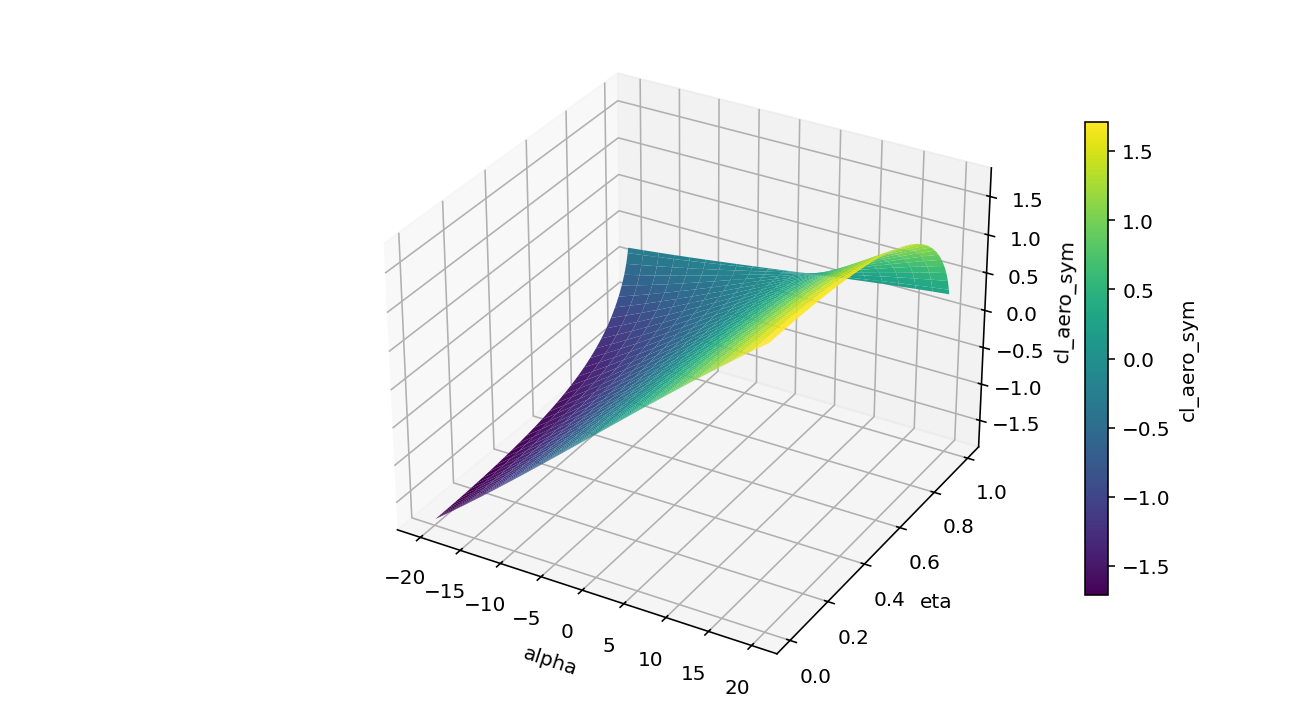

In [15]:
# cl_aero_sym_table.plot(figsize=(8, 5), xlabel="eta", ylabel="cl_aero_sym", grid=True)
plot_df3d(cl_aero_sym_table, zlabel="cl_aero_sym")

<IPython.core.display.Javascript object>


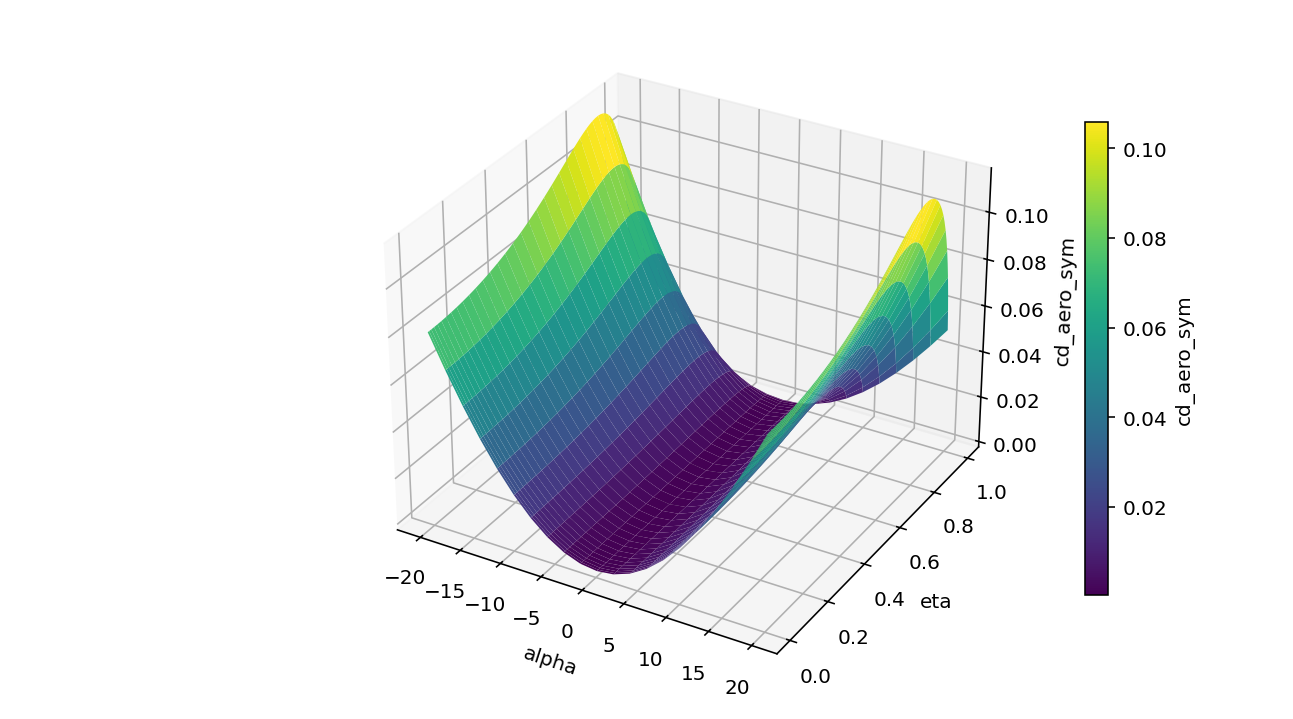

In [16]:
# cd_aero_sym_table.plot(figsize=(8, 5), xlabel="eta", ylabel="cd_aero_sym", grid=True)
plot_df3d(cd_aero_sym_table, zlabel="cd_aero_sym")

<IPython.core.display.Javascript object>


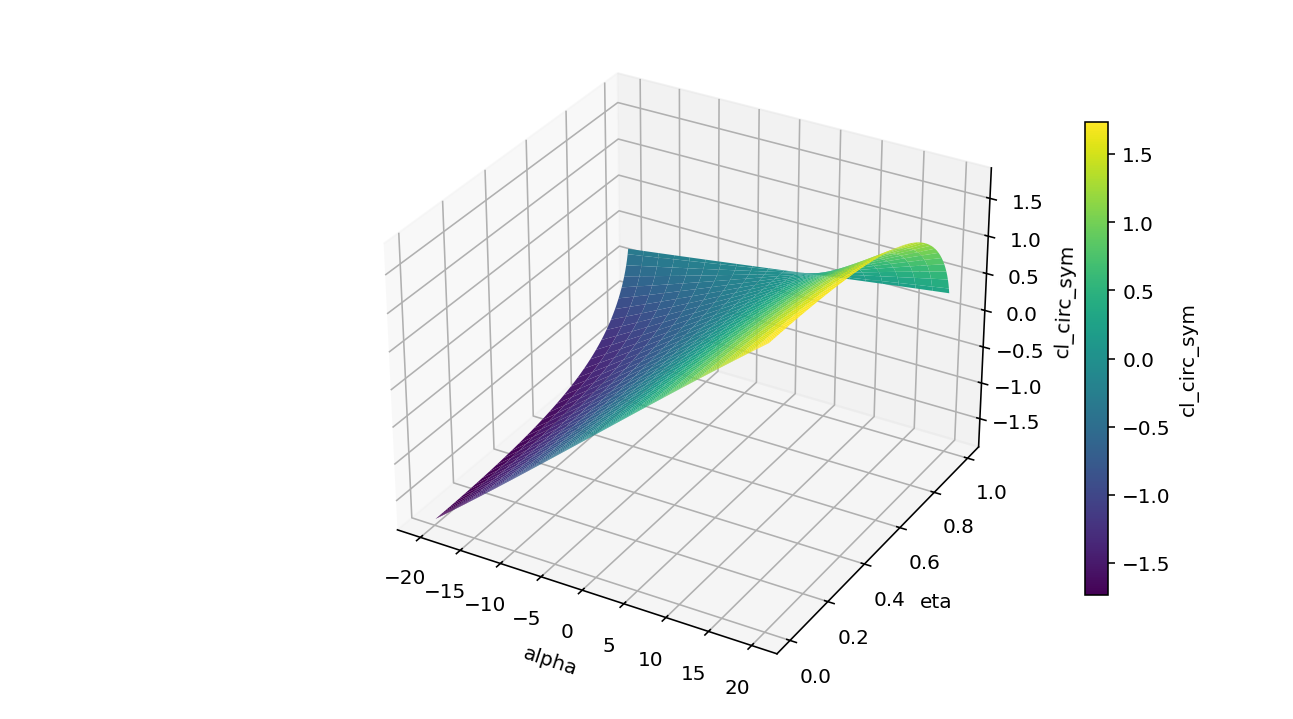

In [17]:
# cl_circ_sym_table.plot(figsize=(8, 5), xlabel="eta", ylabel="cl_circ_sym", grid=True)
plot_df3d(cl_circ_sym_table, zlabel="cl_circ_sym")

### Plot coeffitients for cambered profile

In [18]:
# cl_circ_cam_table.plot(figsize=(8, 5), xlabel="eta", ylabel="cl_circ_cam", grid=True)
# plot_df3d(cl_circ_cam_table, zlabel="Cl_circ_cam")

<IPython.core.display.Javascript object>


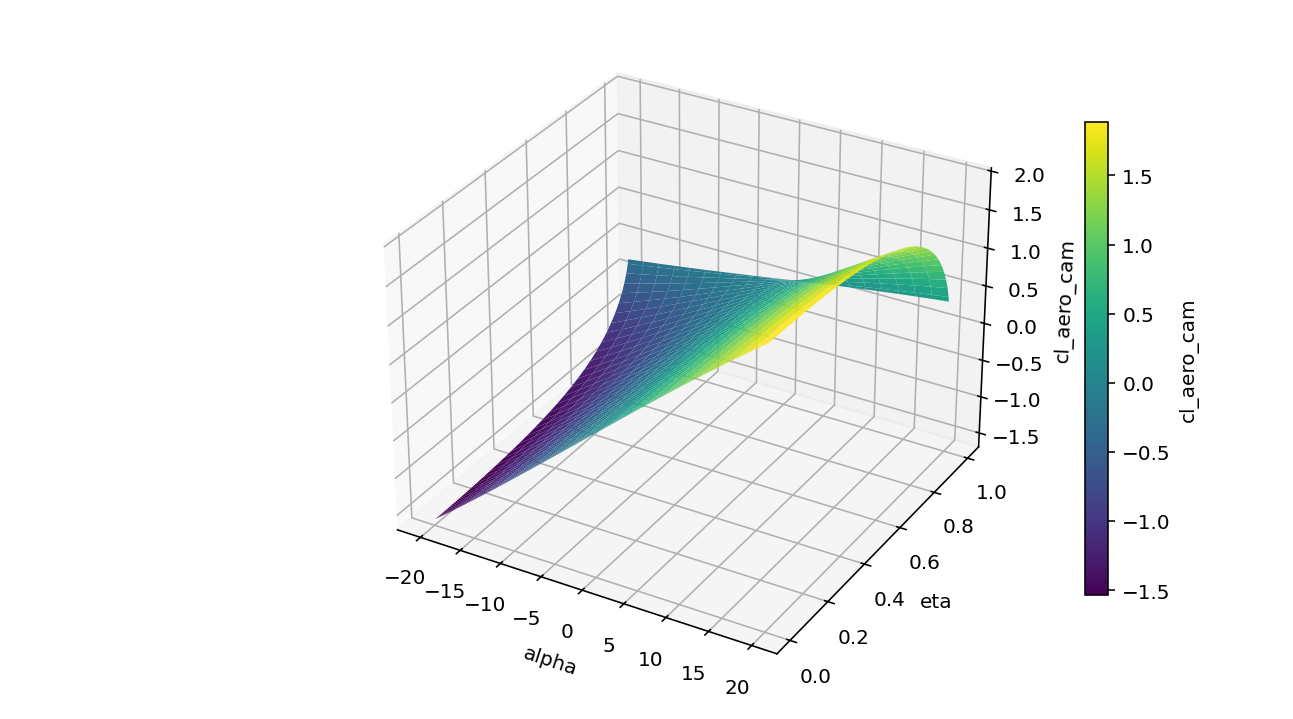

In [19]:
# cl_aero_cam_table.plot(figsize=(8, 5), xlabel="eta", ylabel="cl_aero_cam", grid=True)
plot_df3d(cl_aero_cam_table, zlabel="cl_aero_cam")

<IPython.core.display.Javascript object>


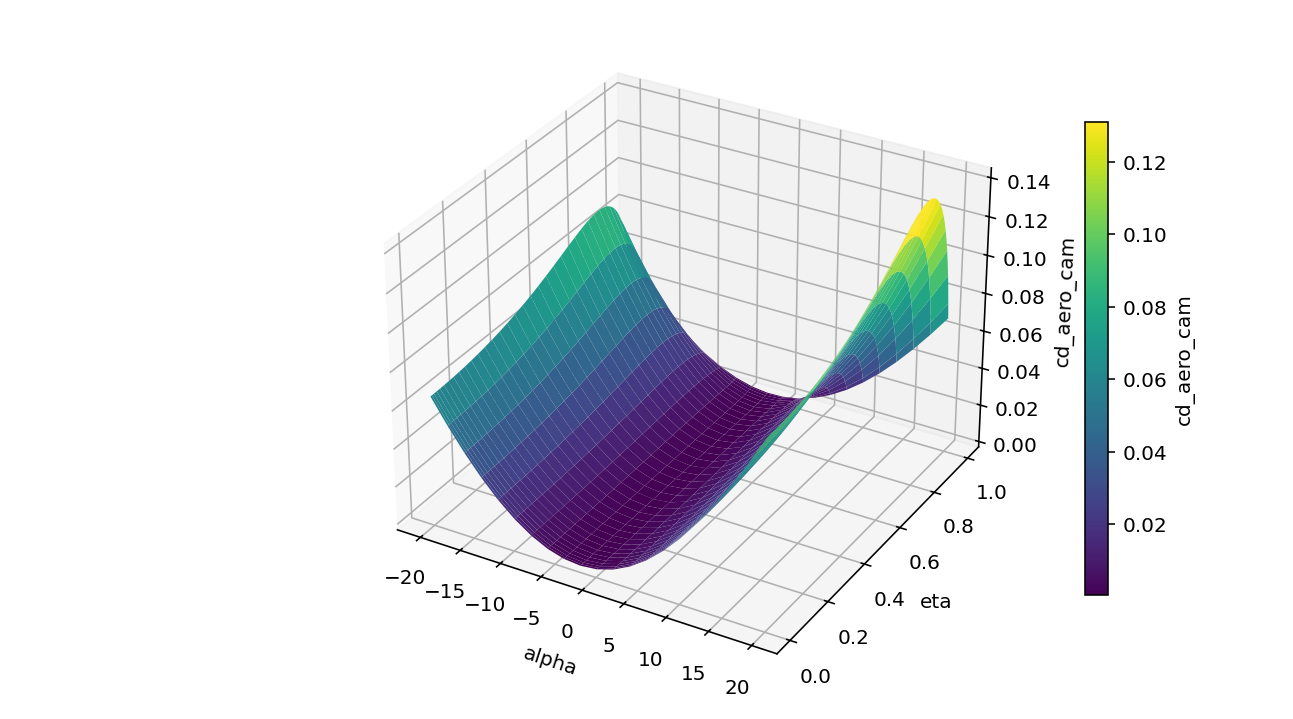

In [20]:
# cd_aero_cam_table.plot(figsize=(8, 5), xlabel="eta", ylabel="cd_aero_cam", grid=True)
plot_df3d(cd_aero_cam_table, zlabel="cd_aero_cam")

## 2. Normalize aerodynamic coefficients by alpha for symmetric airfoil

Apply the following normalization models:

for $c_{l, a}(\eta)$:

$$c_{l, a}^*(\eta) =
\frac{c_{l, a}(\eta, \alpha)}
{\pi \sin(\alpha)
\sqrt{1 + k_\alpha \cos(\alpha)}}$$

for $c_{d, i}(\eta)$:

$$c_{d, {i}}^*(\eta) =
\frac{c_{d, i}(\eta, \alpha)}
{\cos(\alpha)\sin^2(\alpha)}$$


for $c_{l, Г}(\eta)$:

$$c_{l, Г}^*(\eta) =
\frac{c_{l, Г}(\eta, \alpha)}
{\pi \sin(\alpha)}$$


### 2.1 Find optimal normalization coefficient Kalpha

In [21]:
def normalize_cl_sym(cl_table, alpha_values, k_alpha):
    """Apply the sqrt(1 + k_alpha*cos(alpha)) normalization for cl(eta)."""
    norm_table = pd.DataFrame(index=cl_table.index)
    for col in cl_table.columns:
        alpha_deg = alpha_values[col]
        if alpha_deg == int(alpha_zero_lift_sym):
            continue
        
        cl_vals = cl_table[col].to_numpy(dtype=float)
        sin_alpha = np.sin(np.radians(alpha_deg))
        cos_alpha = np.cos(np.radians(alpha_deg))
        
        norm_table[col] = cl_vals / (pi * sin_alpha * np.sqrt(1 + k_alpha * cos_alpha))
    
    return norm_table

In [22]:
def objective(k_alpha, cl_table, alpha_values, center="median"):
    """Mean relative absolute deviation of each row from its own center, averaged over all rows/cols."""
    norm_table = normalize_cl_sym(cl_table, alpha_values, k_alpha)
    row_center = norm_table.median(axis=1) if center == "median" else norm_table.mean(axis=1)

    abs_dev = norm_table.sub(row_center, axis=0).abs()
    rel_dev = abs_dev.div(row_center.abs(), axis=0)

    mre = rel_dev.values.mean()  # mean relative error (fraction, e.g. 0.02 = 2%)
    return mre


result = minimize_scalar(
    objective,
    bounds=(0.0, 20.0),          # search range for the k_alpha coefficient
    method="bounded",
    args=(cl_aero_sym_table, alpha_values, "median"),
    options={"xatol": 1e-6},
)

optimal_k_alpha = round(result.x, 2)
best_mae = result.fun

print(f"Optimal Kalpha: {optimal_k_alpha}")
print(f"MAE at optimum: {best_mae:.6e}")

Optimal Kalpha: 1.93
MAE at optimum: 2.552763e-03


### 2.2 Normalize coefficients

In [23]:
cl_aero_sym_norm_table = pd.DataFrame(index=cl_aero_sym_table.index)
cd_aero_sym_norm_table = pd.DataFrame(index=cl_aero_sym_table.index)
cl_circ_sym_norm_table = pd.DataFrame(index=cl_aero_sym_table.index)

wa_cd_sym_table = pd.DataFrame(index=cl_aero_sym_table.index)
wa_cl_sym_table = pd.DataFrame(index=cl_aero_sym_table.index)

alpha_cols = cl_aero_sym_table.columns
for col in alpha_cols:
    alpha_deg = alpha_values[col]
    if alpha_deg == int(alpha_zero_lift_sym):
        continue
      
    cl_vals = cl_aero_sym_table[col].to_numpy(dtype=float)
    cd_vals = cd_aero_sym_table[col].to_numpy(dtype=float)
    cl_circ_vals = cl_circ_sym_table[col].to_numpy(dtype=float)
    
    sin_alpha = np.sin(np.radians(alpha_deg))
    cos_alpha = np.cos(np.radians(alpha_deg))
    
    cl_aero_sym_norm_table[col] = cl_vals/(pi*sin_alpha*np.sqrt(1+optimal_k_alpha*cos_alpha))
    cd_aero_sym_norm_table[col] = cd_vals/(cos_alpha*sin_alpha**2)
    cl_circ_sym_norm_table[col] = cl_circ_vals/(pi*sin_alpha)
    wa_cd_sym_table[col] = (cd_vals/cl_circ_vals)/(sin_alpha*cos_alpha)
    wa_cl_sym_table[col] = (1-cl_vals/cl_circ_vals)/(sin_alpha**2)

<IPython.core.display.Javascript object>


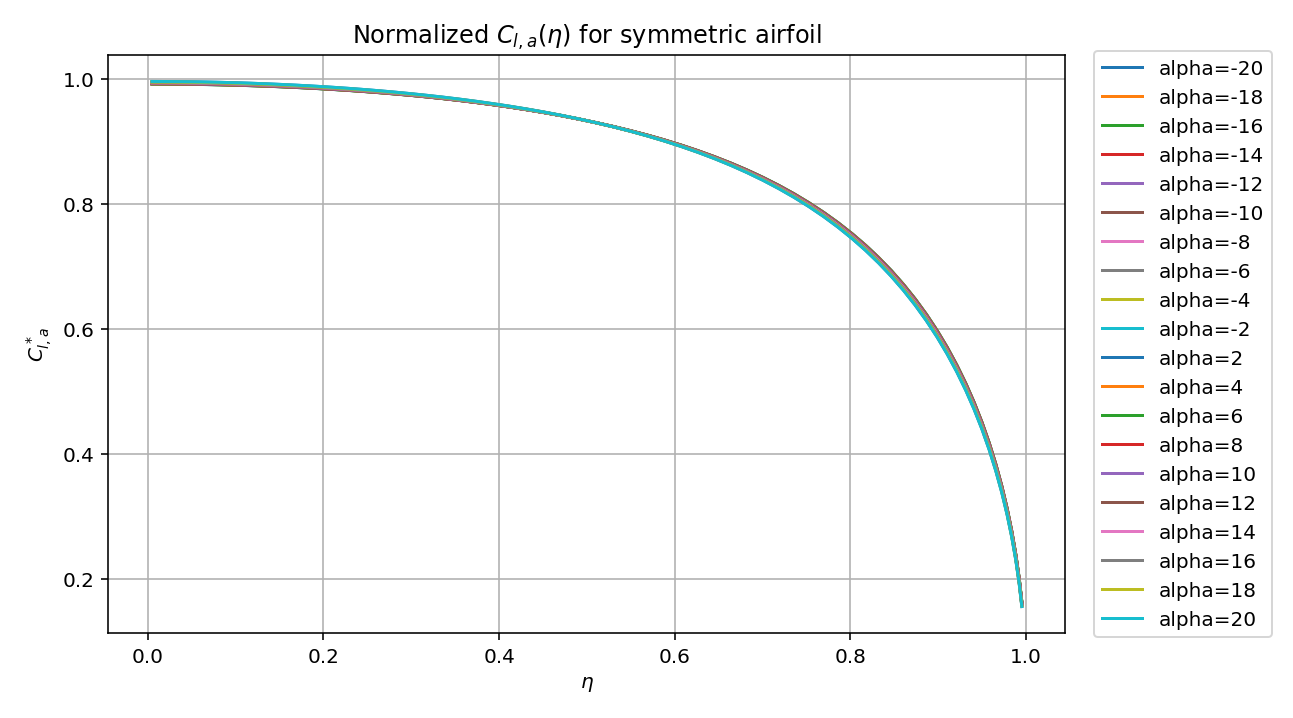

In [24]:
ax = cl_aero_sym_norm_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$C_{l, a}^*$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"Normalized $C_{l, a}(\eta)$ for symmetric airfoil")
ax.figure.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


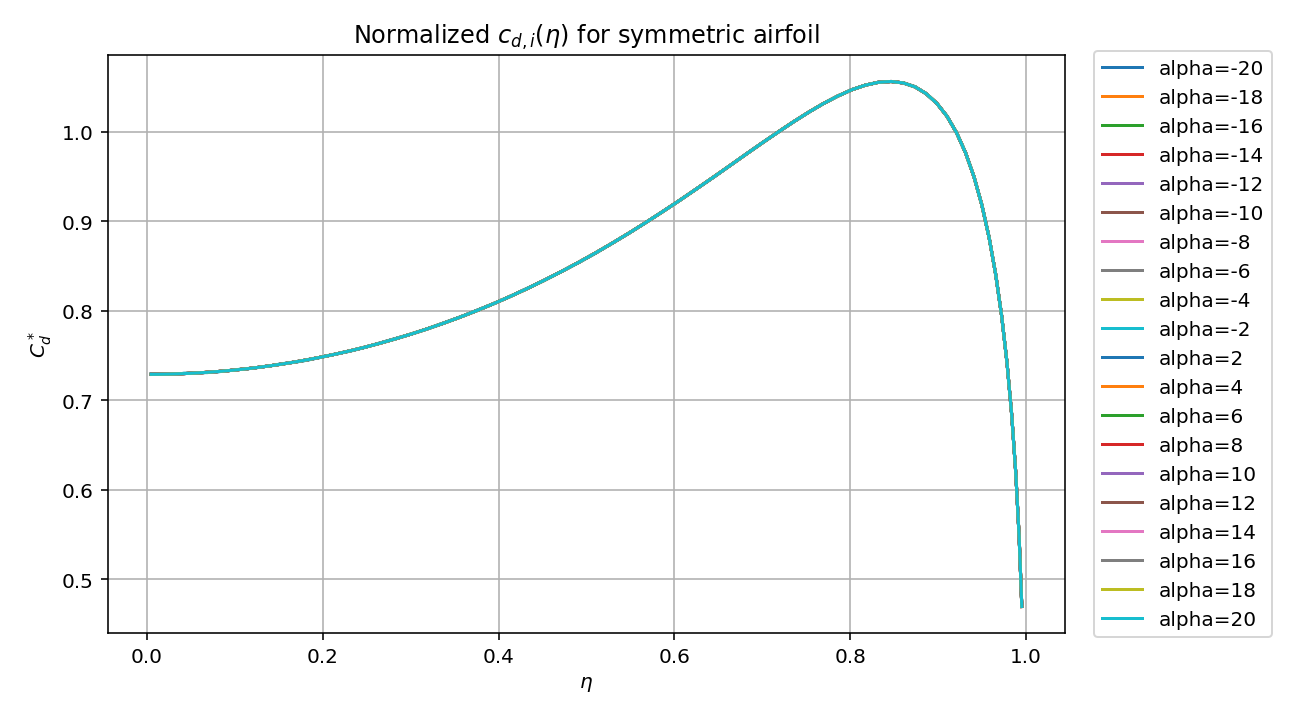

In [25]:
ax = cd_aero_sym_norm_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$C_d^*$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"Normalized $c_{d, i}(\eta)$ for symmetric airfoil")
ax.figure.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


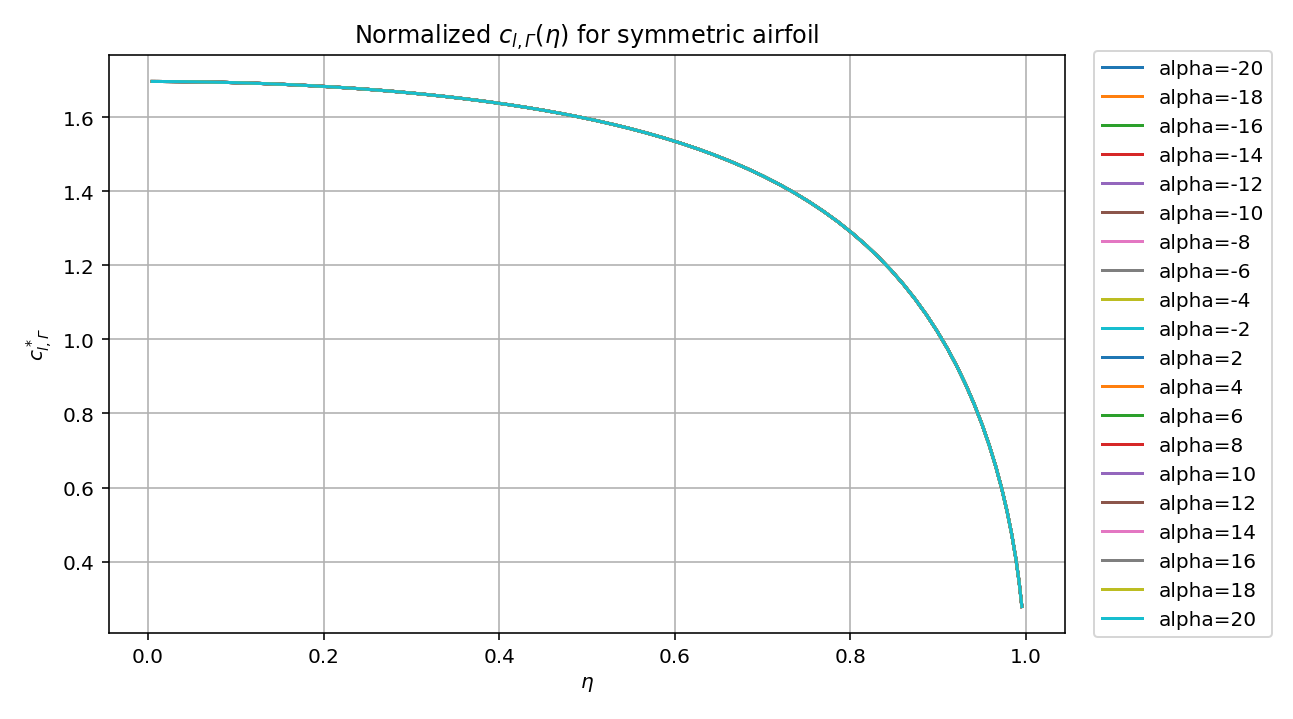

In [26]:
ax = cl_circ_sym_norm_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$с_{l,Г}^*$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"Normalized $с_{l,Г}(\eta)$ for symmetric airfoil")
ax.figure.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


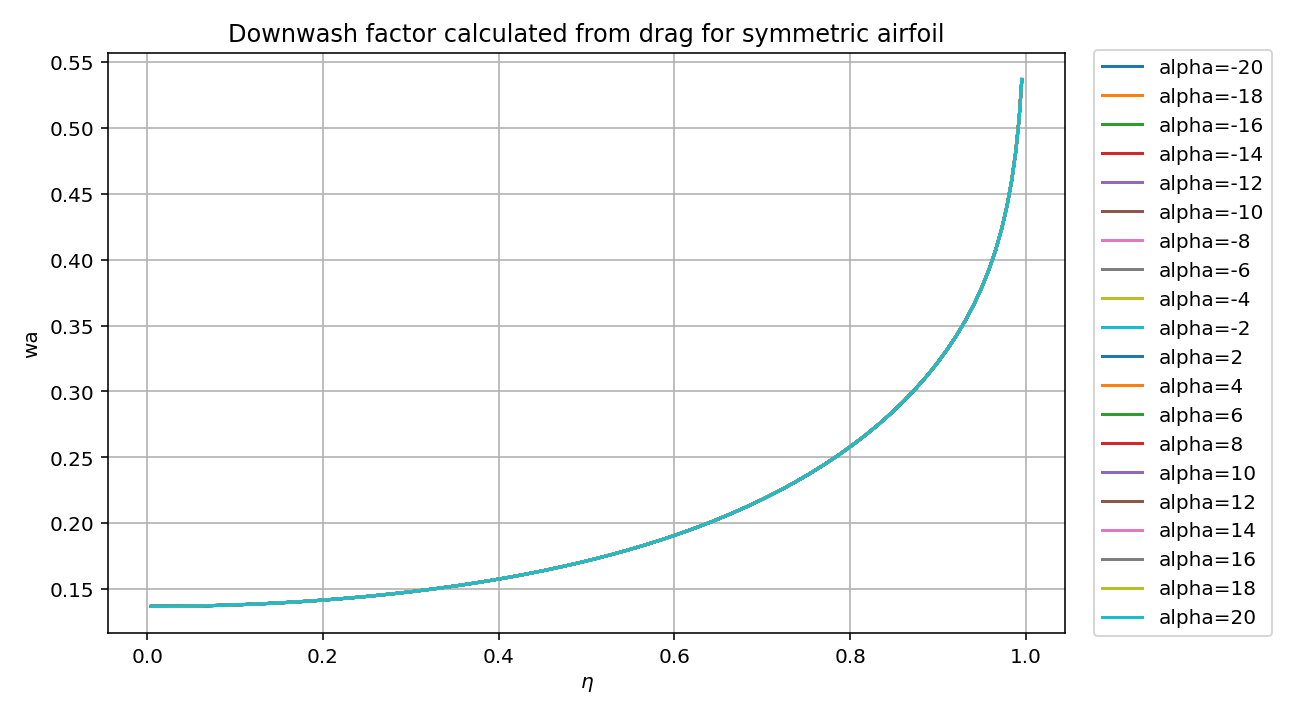

In [27]:
ax = wa_cd_sym_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"wa", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title("Downwash factor calculated from drag for symmetric airfoil")
ax.figure.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


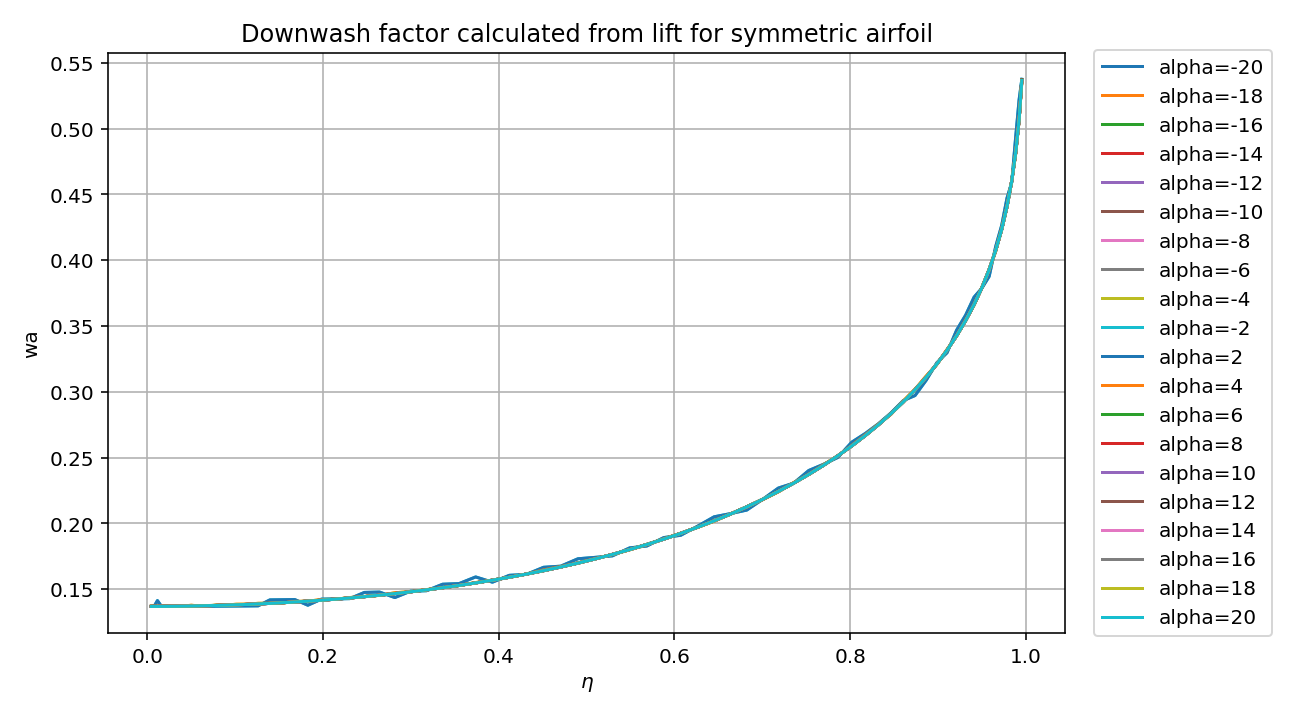

In [28]:
ax = wa_cl_sym_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"wa", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title("Downwash factor calculated from lift for symmetric airfoil")
ax.figure.tight_layout()
plt.show()

## 3. Normalize aerodynamic coefficients for cambered airfoil


Apply the following normalization models:

for $c_{l, a}(\eta)$:

$$c_{l, a}^*(\eta) =
\frac{c_{l, a}(\eta, \alpha)}
{\pi \sin(\alpha - \alpha_0(\eta)) \cdot
\sqrt{1 + k_\alpha \cos(\alpha)}}$$

for $c_{d, i}(\eta)$:

$$c_{d, i}^*(\eta) =
\frac{c_{d, i}(\eta, \alpha)}
{\cos(\alpha - \alpha_{mindrag}(\eta)) \cdot (\sin(\alpha) - \sin(\alpha_{mindrag}))^2}$$


for $c_{l, Г}(\eta)$:

$$c_{l, Г}^*(\eta) =
\frac{c_{l, Г}(\eta, \alpha)}
{\pi \sin(\alpha - \alpha_0(\eta))}$$

### 3.1 Find  $\alpha_0(\eta)$ law

In [29]:
def find_zero_lift(alphas, cl_data, poly_func, popt):
    """
    Find alpha_zero_lift = root of poly_func(alpha; popt) = 0.
 
    Bracket is taken from the RAW DATA sign change (robust, since cl(alpha) is
    quasi-linear and crosses zero exactly once.
    """
    sign = np.sign(cl_data)
    # index where data goes from negative (or zero) to positive
    cross_idx = np.where(np.diff(sign) > 0)[0]
 
    if len(cross_idx) == 0:
        # no sign change in the data (e.g. always positive/negative) ->
        # cannot bracket; report NaN rather than guessing
        return np.nan
 
    i = cross_idx[0]           # first crossing = physically meaningful one
    a, b = alphas[i], alphas[i + 1]
 
    f = lambda x: poly_func(x, *popt)
    # guard: fitted curve must actually bracket zero at (a, b) too
    if f(a) * f(b) > 0:
        # fit deviates slightly from data at the bracket edges -> widen a touch
        pad = 0.5 * (b - a)
        a, b = a - pad, b + pad
 
    return brentq(f, a, b)

In [30]:
def fit_cl_surface(cl_table, r2_threshold=0.995):

    records = []
    fit_store = {}
 
    for eta_val, row in cl_table.iterrows():
        cl = row[alpha_cols].values.astype(float)
 
        popt2, _ = curve_fit(poly2, alphas, cl, p0=[0.0, 0.1, 0.0])
        r2_2 = r_squared(cl, poly2(alphas, *popt2))
 
        popt4, _ = curve_fit(poly4, alphas, cl, p0=[0.0, 0.0, 0.0, 0.1, 0.0],
                              maxfev=10000)
        r2_4 = r_squared(cl, poly4(alphas, *popt4))
 
        if r2_4 >= r2_threshold:
            popt, poly_func, method, r2_used = popt4, poly4, 'poly4', r2_4
        elif r2_2 >= r2_threshold:
            popt, poly_func, method, r2_used = popt2, poly2, 'poly2', r2_2
        else:
            raise ValueError("Failed to find polinomial fit")

        alpha0 = find_zero_lift(alphas, cl, poly_func, popt)
        records.append(dict(eta=eta_val, alpha_zero_lift=alpha0,
                             method=method, r2=r2_used))
        fit_store[eta_val] = dict(alphas=alphas, cl=cl, method=method,
                                   popt2=popt2, popt4=popt4)
 
    return pd.DataFrame.from_records(records), fit_store, alphas

In [31]:
results, fit_store, alphas = fit_cl_surface(cl_aero_cam_table)
print(results['method'].value_counts())

method
poly4    74
Name: count, dtype: int64


In [32]:
alpha_zero_lift = results["alpha_zero_lift"].to_numpy()
# alpha_zero_lift

<IPython.core.display.Javascript object>


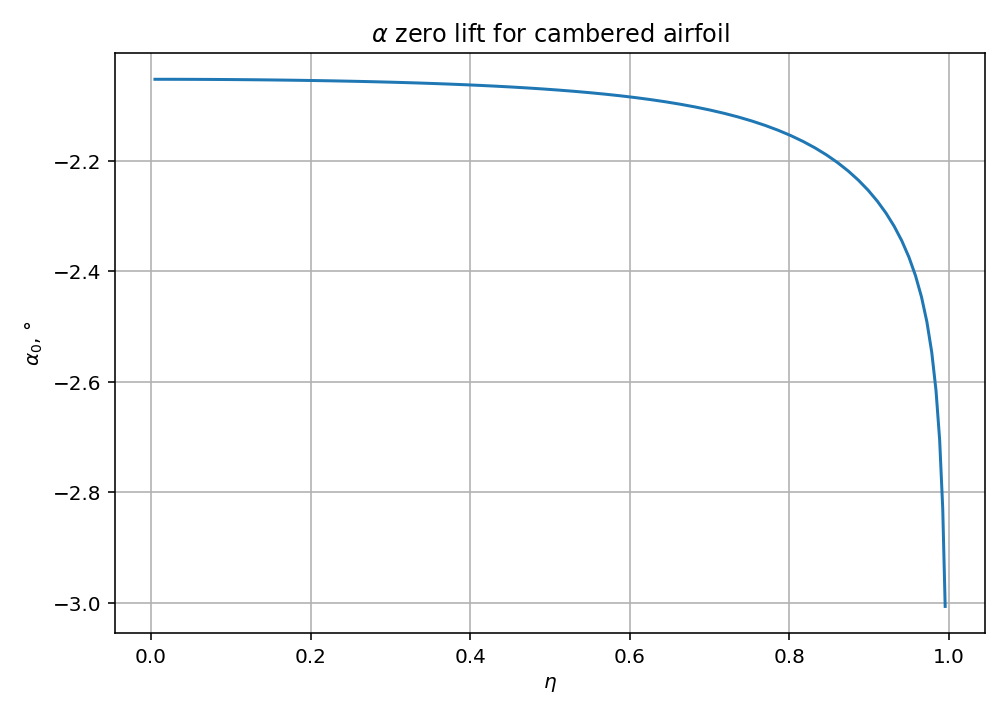

In [33]:
# Plot alpha zero lift
fig = plt.figure(figsize=(7, 5))

ax = fig.add_subplot(111)
ax.set_title(r"$\alpha$ zero lift for cambered airfoil")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\alpha_0$, °")
ax.plot(etas, alpha_zero_lift)

plt.grid()
plt.tight_layout()
plt.show()

In [34]:
results, fit_store, alphas = fit_cl_surface(cl_circ_cam_table)
print(results['method'].value_counts())
# print(results.head(10).to_string(index=False))

method
poly4    74
Name: count, dtype: int64


In [35]:
alpha_zero_lift_circ = results["alpha_zero_lift"].to_numpy()

In [36]:
alpha_zero_lift_circ

array([-2.0523081 , -2.0523095 , -2.05231603, -2.05232233, -2.05233366,
       -2.05234756, -2.05237001, -2.05240069, -2.05244009, -2.05249072,
       -2.05255685, -2.05263517, -2.05273275, -2.05285106, -2.05298691,
       -2.05315129, -2.05334048, -2.05356123, -2.05381629, -2.05410676,
       -2.05443753, -2.05480987, -2.0552352 , -2.05570827, -2.05623918,
       -2.05683493, -2.05749821, -2.05823298, -2.05904998, -2.0599592 ,
       -2.06096215, -2.06207513, -2.06330099, -2.06465431, -2.06615347,
       -2.06780597, -2.06962489, -2.07163868, -2.07385655, -2.07630235,
       -2.07900233, -2.08198218, -2.08527015, -2.08890283, -2.09291117,
       -2.09733522, -2.10221884, -2.10760761, -2.11355661, -2.12011788,
       -2.12734587, -2.13531247, -2.14407309, -2.1537043 , -2.16427219,
       -2.1758545 , -2.1885404 , -2.20240727, -2.21755143, -2.23408318,
       -2.25212775, -2.27185217, -2.29344881, -2.31720761, -2.34351457,
       -2.37290062, -2.4061638 , -2.44444635, -2.48952196, -2.54

<IPython.core.display.Javascript object>


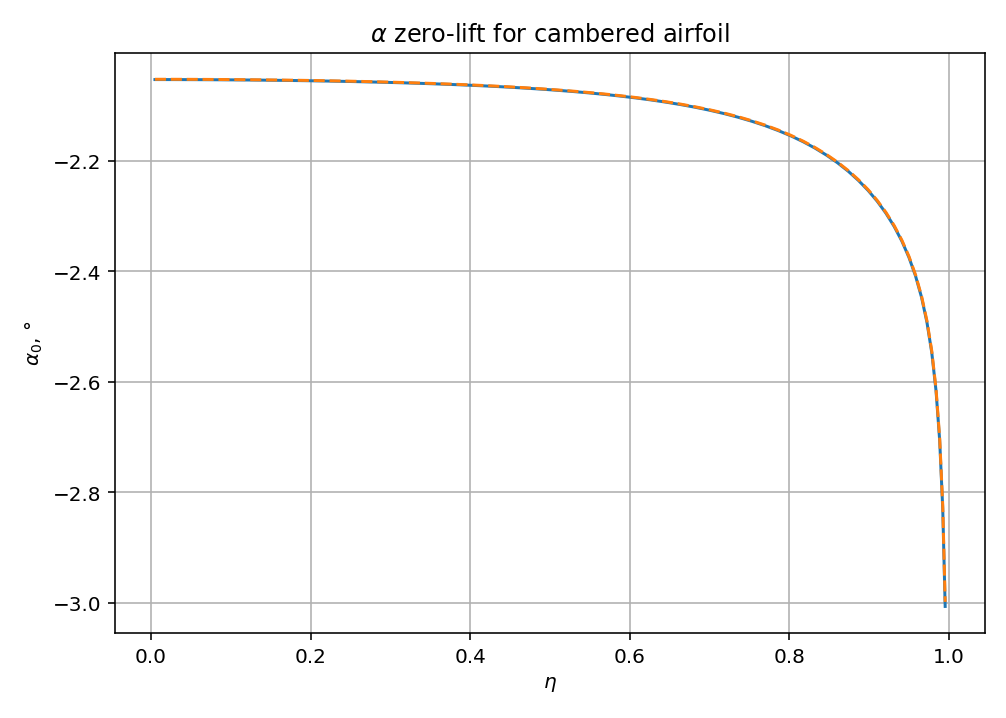

In [37]:
# Plot alpha zero lift
fig = plt.figure(figsize=(7, 5))

ax = fig.add_subplot(111)
ax.set_title(r"$\alpha$ zero-lift for cambered airfoil")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\alpha_0$, °")
ax.plot(etas, alpha_zero_lift)
ax.plot(etas, alpha_zero_lift_circ, "--")

plt.grid()
plt.tight_layout()
plt.show()

### 3.2 Normalize $c_{l, {a}}$ and $c_{l, {Г}}$

In [38]:
cl_aero_cam_norm_table = pd.DataFrame(index=cl_aero_cam_table.index)
cl_circ_cam_norm_table = pd.DataFrame(index=cl_circ_cam_table.index)

alpha_cols = cl_aero_sym_table.columns
for col in alpha_cols:
    alpha_deg = alpha_values[col] 
    
    cl_vals = cl_aero_cam_table[col].to_numpy(dtype=float)
    cl_circ_vals = cl_circ_cam_table[col].to_numpy(dtype=float)
    
    sin_alpha = np.sin(np.radians(alpha_deg))
    cos_alpha = np.cos(np.radians(alpha_deg))
    
    sin_alpha_cam = np.sin(np.radians(alpha_deg - alpha_zero_lift_circ))
    cos_alpha_cam = np.cos(np.radians(alpha_deg - alpha_zero_lift_circ))
    
    sin_alpha_0 = np.sin(np.radians(alpha_zero_lift_circ))
    cos_alpha_0 = np.cos(np.radians(alpha_zero_lift_circ))
    
    cl_aero_cam_norm_table[col] = cl_vals / (pi*sin_alpha_cam * np.sqrt(1 + optimal_k_alpha*cos_alpha))
    cl_circ_cam_norm_table[col] = cl_circ_vals / (pi*sin_alpha_cam)

<IPython.core.display.Javascript object>


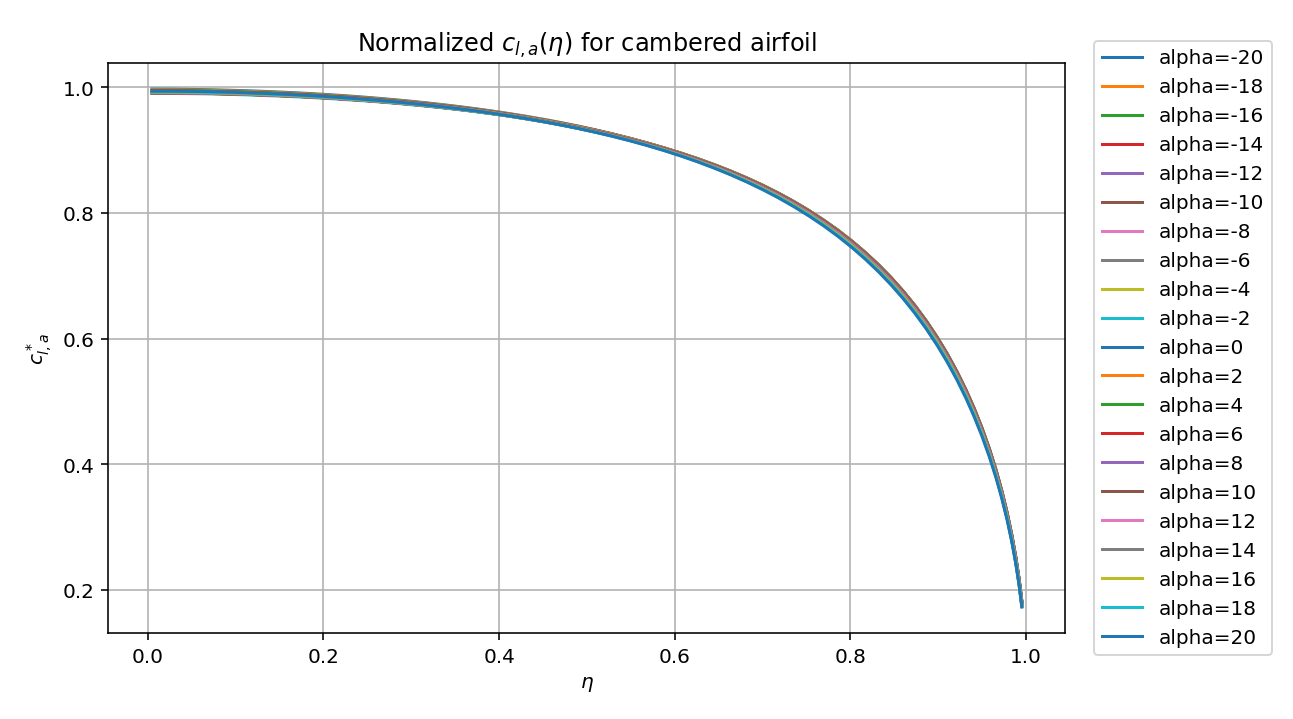

In [39]:
ax = cl_aero_cam_norm_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$c_{l,a}^*$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"Normalized $с_{l,a}(\eta)$ for cambered airfoil")
ax.figure.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


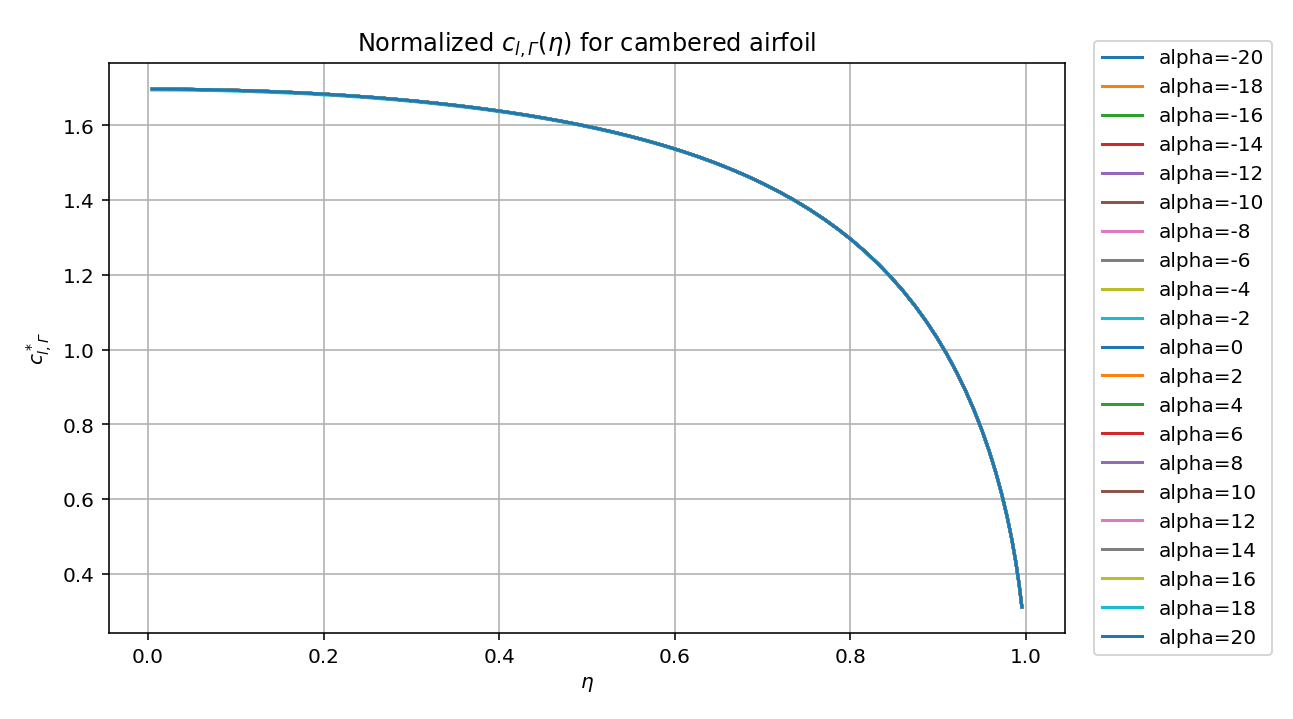

In [40]:
ax = cl_circ_cam_norm_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$c_{l,Г}^*$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"Normalized $c_{l,Г}(\eta)$ for cambered airfoil")
ax.figure.tight_layout()
plt.show()

### 3.3 Estimate normalization errors

#### Compare Cl norm for symmetric and cambered airfoils

In [41]:
## pick single curve from symmetric airfoil normalized results
alpha_ref = 8
alpha_ref_sym = alpha_ref + int(alpha_zero_lift_sym)
alpha_ref_cam = alpha_ref + int(alpha_zero_lift_cam)

In [42]:
cl_norm_sym = cl_aero_sym_norm_table[f"alpha={alpha_ref_sym}"].to_numpy() 
cl_norm_cam = cl_aero_cam_norm_table[f"alpha={alpha_ref_cam}"].to_numpy()

cl_norm_diff = cl_norm_sym - cl_norm_cam
cl_norm_diff

array([ 4.47710685e-04,  4.46488879e-04,  4.47172074e-04,  4.46412835e-04,
        4.47493600e-04,  4.47410308e-04,  4.48183408e-04,  4.47069853e-04,
        4.46748324e-04,  4.46140382e-04,  4.45713463e-04,  4.43668184e-04,
        4.40800847e-04,  4.38564103e-04,  4.35165929e-04,  4.29197455e-04,
        4.22786106e-04,  4.15328106e-04,  4.07083707e-04,  3.96726230e-04,
        3.84746636e-04,  3.68506740e-04,  3.53259843e-04,  3.34205709e-04,
        3.13744197e-04,  2.89871253e-04,  2.64032294e-04,  2.35126114e-04,
        2.02852599e-04,  1.66775170e-04,  1.26731484e-04,  8.29468191e-05,
        3.53077936e-05, -1.76202626e-05, -7.55917765e-05, -1.38407059e-04,
       -2.06634205e-04, -2.81863904e-04, -3.64053290e-04, -4.54314900e-04,
       -5.51043957e-04, -6.56944313e-04, -7.72025346e-04, -8.97040630e-04,
       -1.03242883e-03, -1.17807538e-03, -1.33659692e-03, -1.50843048e-03,
       -1.69631935e-03, -1.89613433e-03, -2.11370278e-03, -2.34615759e-03,
       -2.59867623e-03, -

<IPython.core.display.Javascript object>


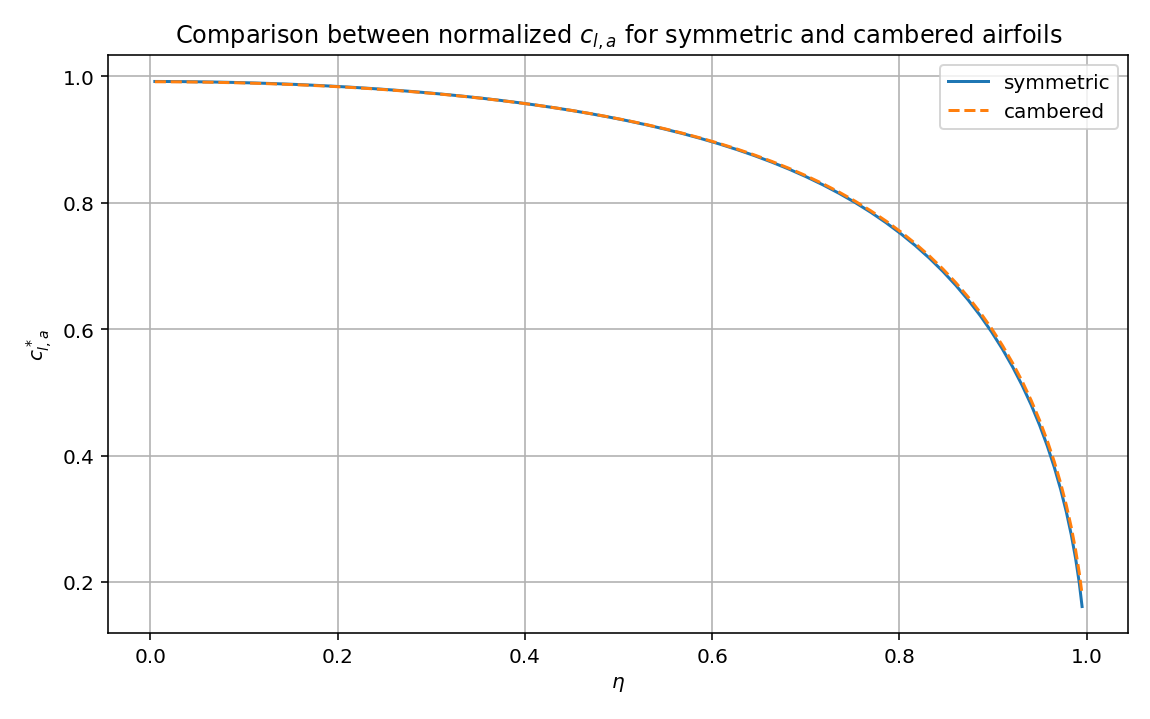

In [43]:
# Plot Cl normalized
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(etas, cl_norm_sym, label="symmetric")
ax.plot(etas, cl_norm_cam, "--", label="cambered")

ax.set_title(r"Comparison between normalized $c_{l, a}$ for symmetric and cambered airfoils")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$c_{l, a}^*$")

ax.legend()
plt.grid()
plt.tight_layout()
plt.show()

#### Compare ClГ and Cla

In [44]:
cl_aero_sym_norm = cl_aero_sym_norm_table[f"alpha={alpha_ref_sym}"].to_numpy() 
cl_circ_sym_norm = cl_circ_sym_norm_table[f"alpha={alpha_ref_sym}"].to_numpy()

cl_sym_norm_ratio = cl_circ_sym_norm/cl_aero_sym_norm
# cl_sym_norm_ratio

In [45]:
## pick single curve from symmetric airfoil normalized results
cl_aero_cam_norm = cl_aero_cam_norm_table[f"alpha={alpha_ref_cam}"].to_numpy() 
cl_circ_cam_norm = cl_circ_cam_norm_table[f"alpha={alpha_ref_cam}"].to_numpy()

cl_cam_norm_ratio = cl_circ_cam_norm/cl_aero_cam_norm
# cl_cam_norm_ratio

<IPython.core.display.Javascript object>


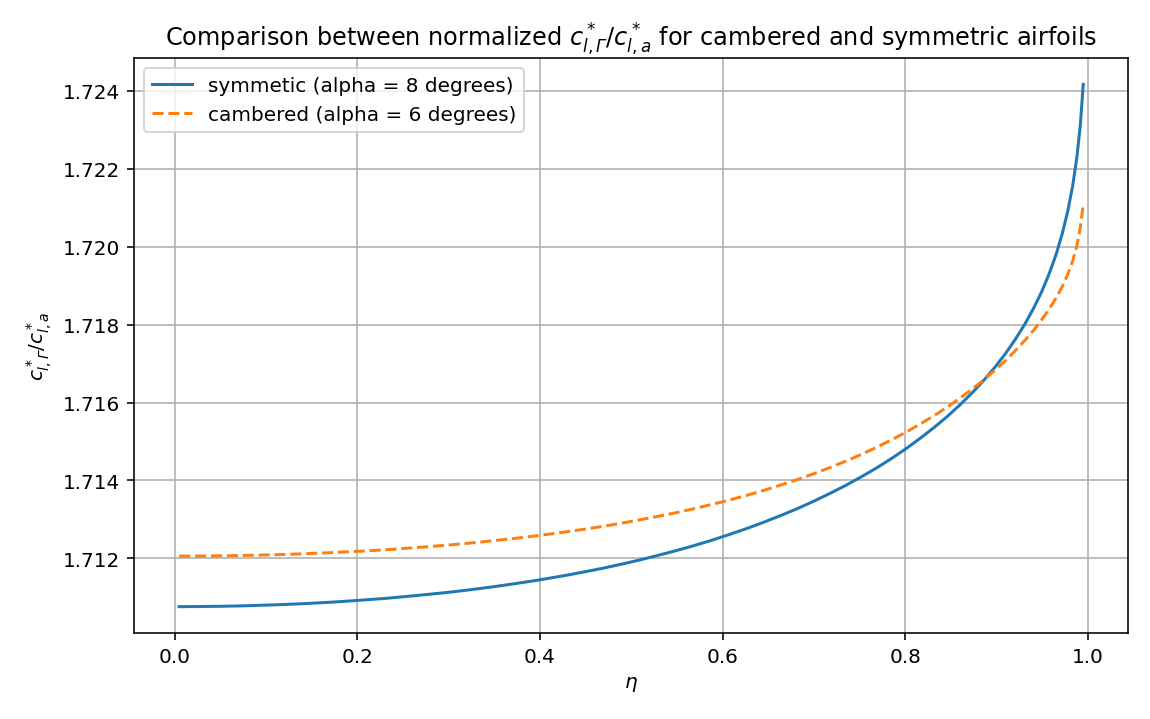

In [46]:
# Plot Cl normalized
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.plot(etas, cl_sym_norm_ratio, label=f"symmetic (alpha = {alpha_ref_sym} degrees)")
ax.plot(etas, cl_cam_norm_ratio, "--", label=f"cambered (alpha = {alpha_ref_cam} degrees)")
ax.set_title(r"Comparison between normalized $c_{l, Г}^*/c_{l, a}^*$ for cambered and symmetric airfoils")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$c_{l, Г}^*/c_{l, a}^*$")

ax.legend()
plt.grid()
plt.tight_layout()
plt.show()

### 3.4 Estimate Cl prediction errors

In [47]:
def eval_cl_aero_pred_sym(alpha_deg):
    sin_alpha = np.sin(np.radians(alpha_deg))
    cos_alpha = np.cos(np.radians(alpha_deg))
    cl_aero_pred = cl_aero_sym_norm * pi * sin_alpha * np.sqrt(1+optimal_k_alpha*cos_alpha)
    
    return np.array(cl_aero_pred) 

In [48]:
def eval_cl_circ_pred_sym(alpha_deg):
    sin_alpha = np.sin(np.radians(alpha_deg))
    cos_alpha = np.cos(np.radians(alpha_deg))
    cl_circ_pred = cl_circ_sym_norm * pi * sin_alpha 
    
    return np.array(cl_circ_pred) 

In [49]:
def eval_cl_aero_pred_cam(alpha_deg):
    cos_alpha = np.cos(np.radians(alpha_deg))
    sin_alpha_cam = np.sin(np.radians(alpha_deg - alpha_zero_lift_circ))
    cl_aero_pred = cl_aero_sym_norm * pi * sin_alpha_cam * np.sqrt(1+optimal_k_alpha*cos_alpha) 
    
    return np.array(cl_aero_pred)

In [50]:
def eval_cl_circ_pred_cam(alpha_deg):
    cos_alpha = np.cos(np.radians(alpha_deg))
    sin_alpha_cam = np.sin(np.radians(alpha_deg - alpha_zero_lift_circ))
    cl_circ_pred = cl_circ_sym_norm * pi * sin_alpha_cam 
    
    return np.array(cl_circ_pred) 

In [51]:
def compare_coeff_predict(coeff_table, pred_func, y_label, alphas):
    
    n = len(alphas)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(9, 4 * nrows),
        squeeze=False
    )
    
    axes = axes.flatten()
    
    for ax, alpha_deg in zip(axes, alphas):
        
        coeff = coeff_table[f"alpha={int(alpha_deg)}"].to_numpy()
        coeff_pred = pred_func(alpha_deg)
        
        rmse = np.sqrt(np.mean((coeff - coeff_pred)**2))
        rrmse = rmse / np.sqrt(np.mean(coeff**2))
        
        ax.plot(etas, coeff, label="Solver")
        ax.plot(etas, coeff_pred, "--", label="Model")
        
        ax.set_title(f"α = {alpha_deg}°")
        ax.set_xlabel(r"$\eta$")
        ax.set_ylabel(y_label)
        
        ax.text(
            0.98, 0.98,
            f"RMSE = {rmse:.2e}\nRRMSE = {rrmse*100:.2f} %",
            transform=ax.transAxes,
            ha="right",
            va="top"
        )
        
        ax.grid()
        ax.legend()
    
    # Remove unused axes if number of alphas is odd
    for ax in axes[n:]:
        ax.remove()
    
    plt.tight_layout()
    plt.show()

<IPython.core.display.Javascript object>


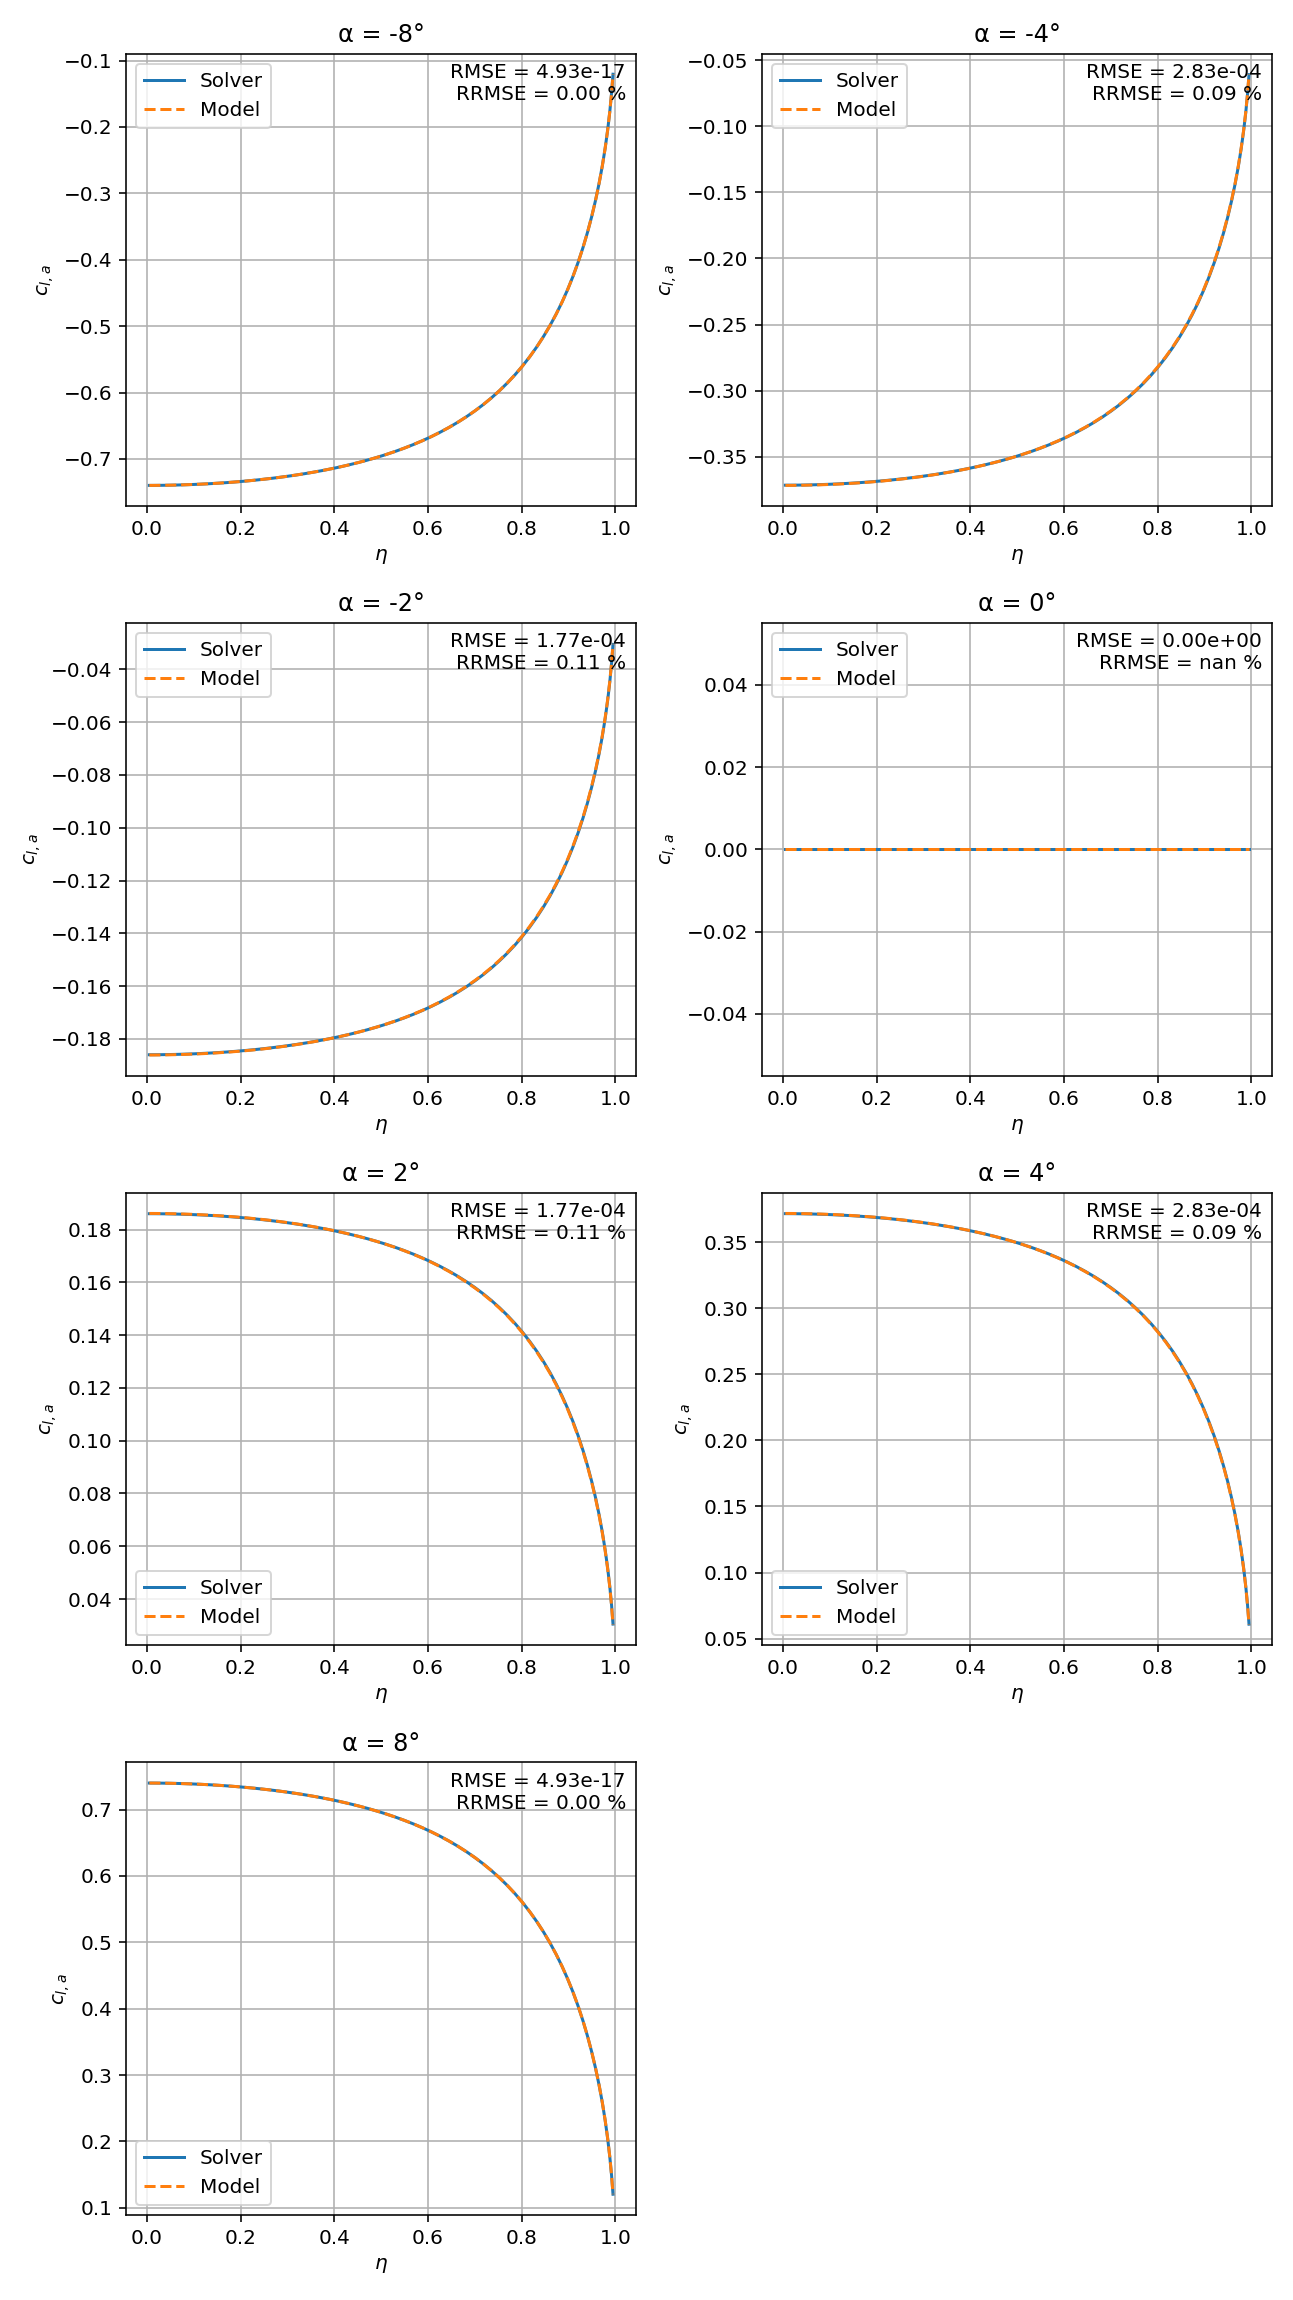

/tmp/ipykernel_297509/297234456.py:21: RuntimeWarning: invalid value encountered in scalar divide
  rrmse = rmse / np.sqrt(np.mean(coeff**2))


In [52]:
compare_coeff_predict(cl_aero_sym_table, eval_cl_aero_pred_sym, "$c_{l, a}$", [-8, -4, -2, 0, 2, 4, 8])

<IPython.core.display.Javascript object>


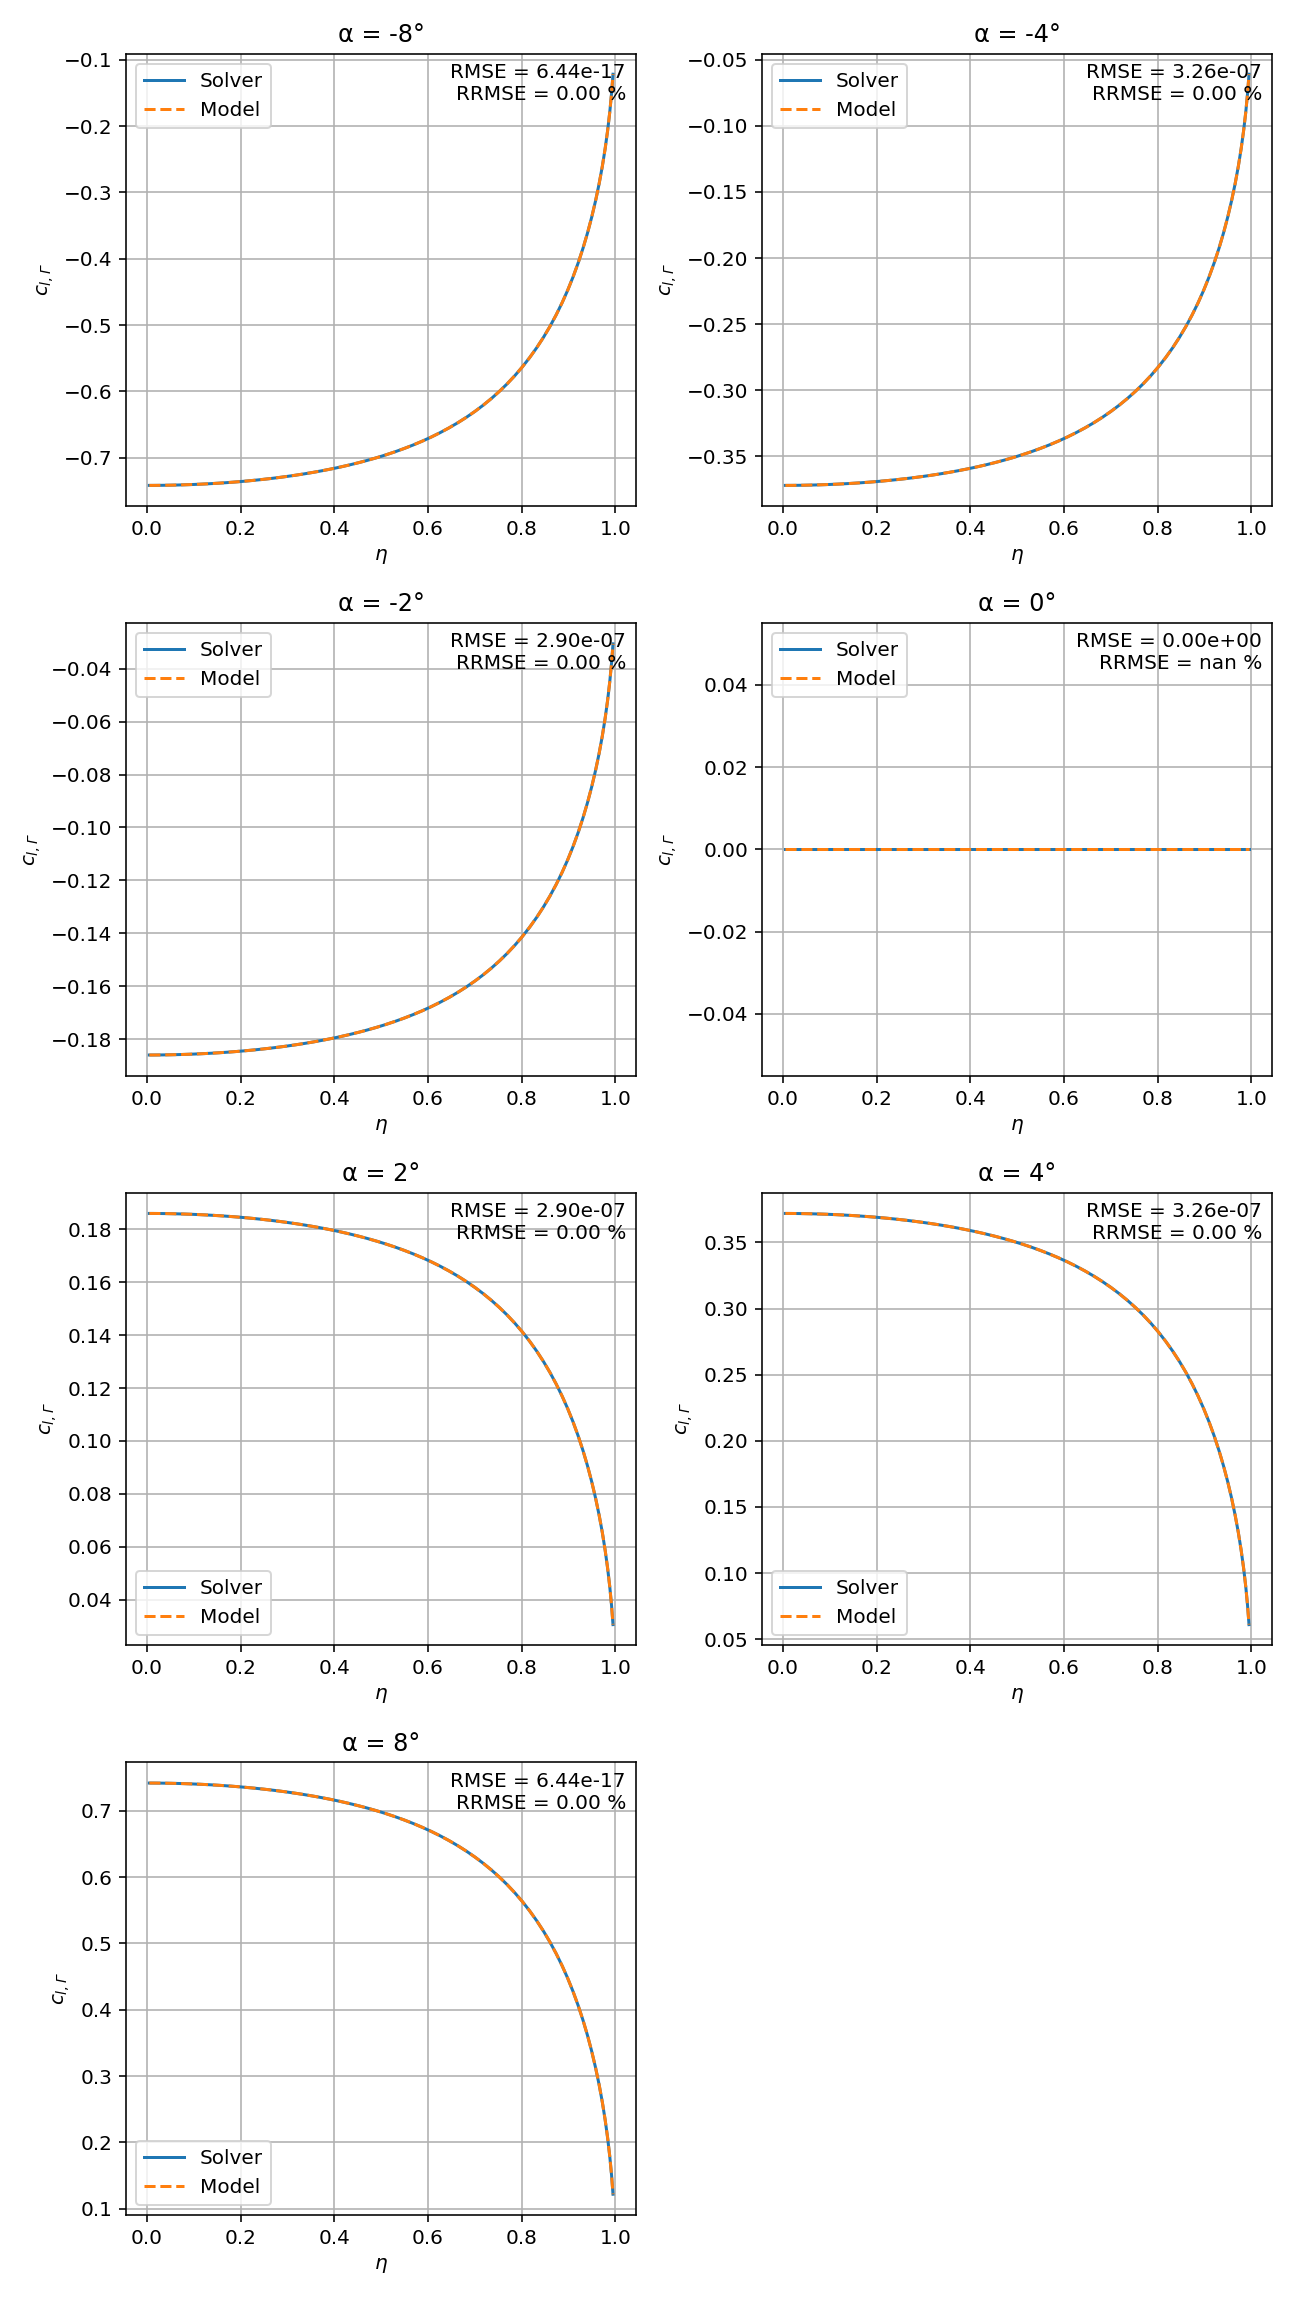

/tmp/ipykernel_297509/297234456.py:21: RuntimeWarning: invalid value encountered in scalar divide
  rrmse = rmse / np.sqrt(np.mean(coeff**2))


In [53]:
compare_coeff_predict(cl_circ_sym_table, eval_cl_circ_pred_sym, "$c_{l, Г}$", [-8, -4, -2, 0, 2, 4, 8])

<IPython.core.display.Javascript object>


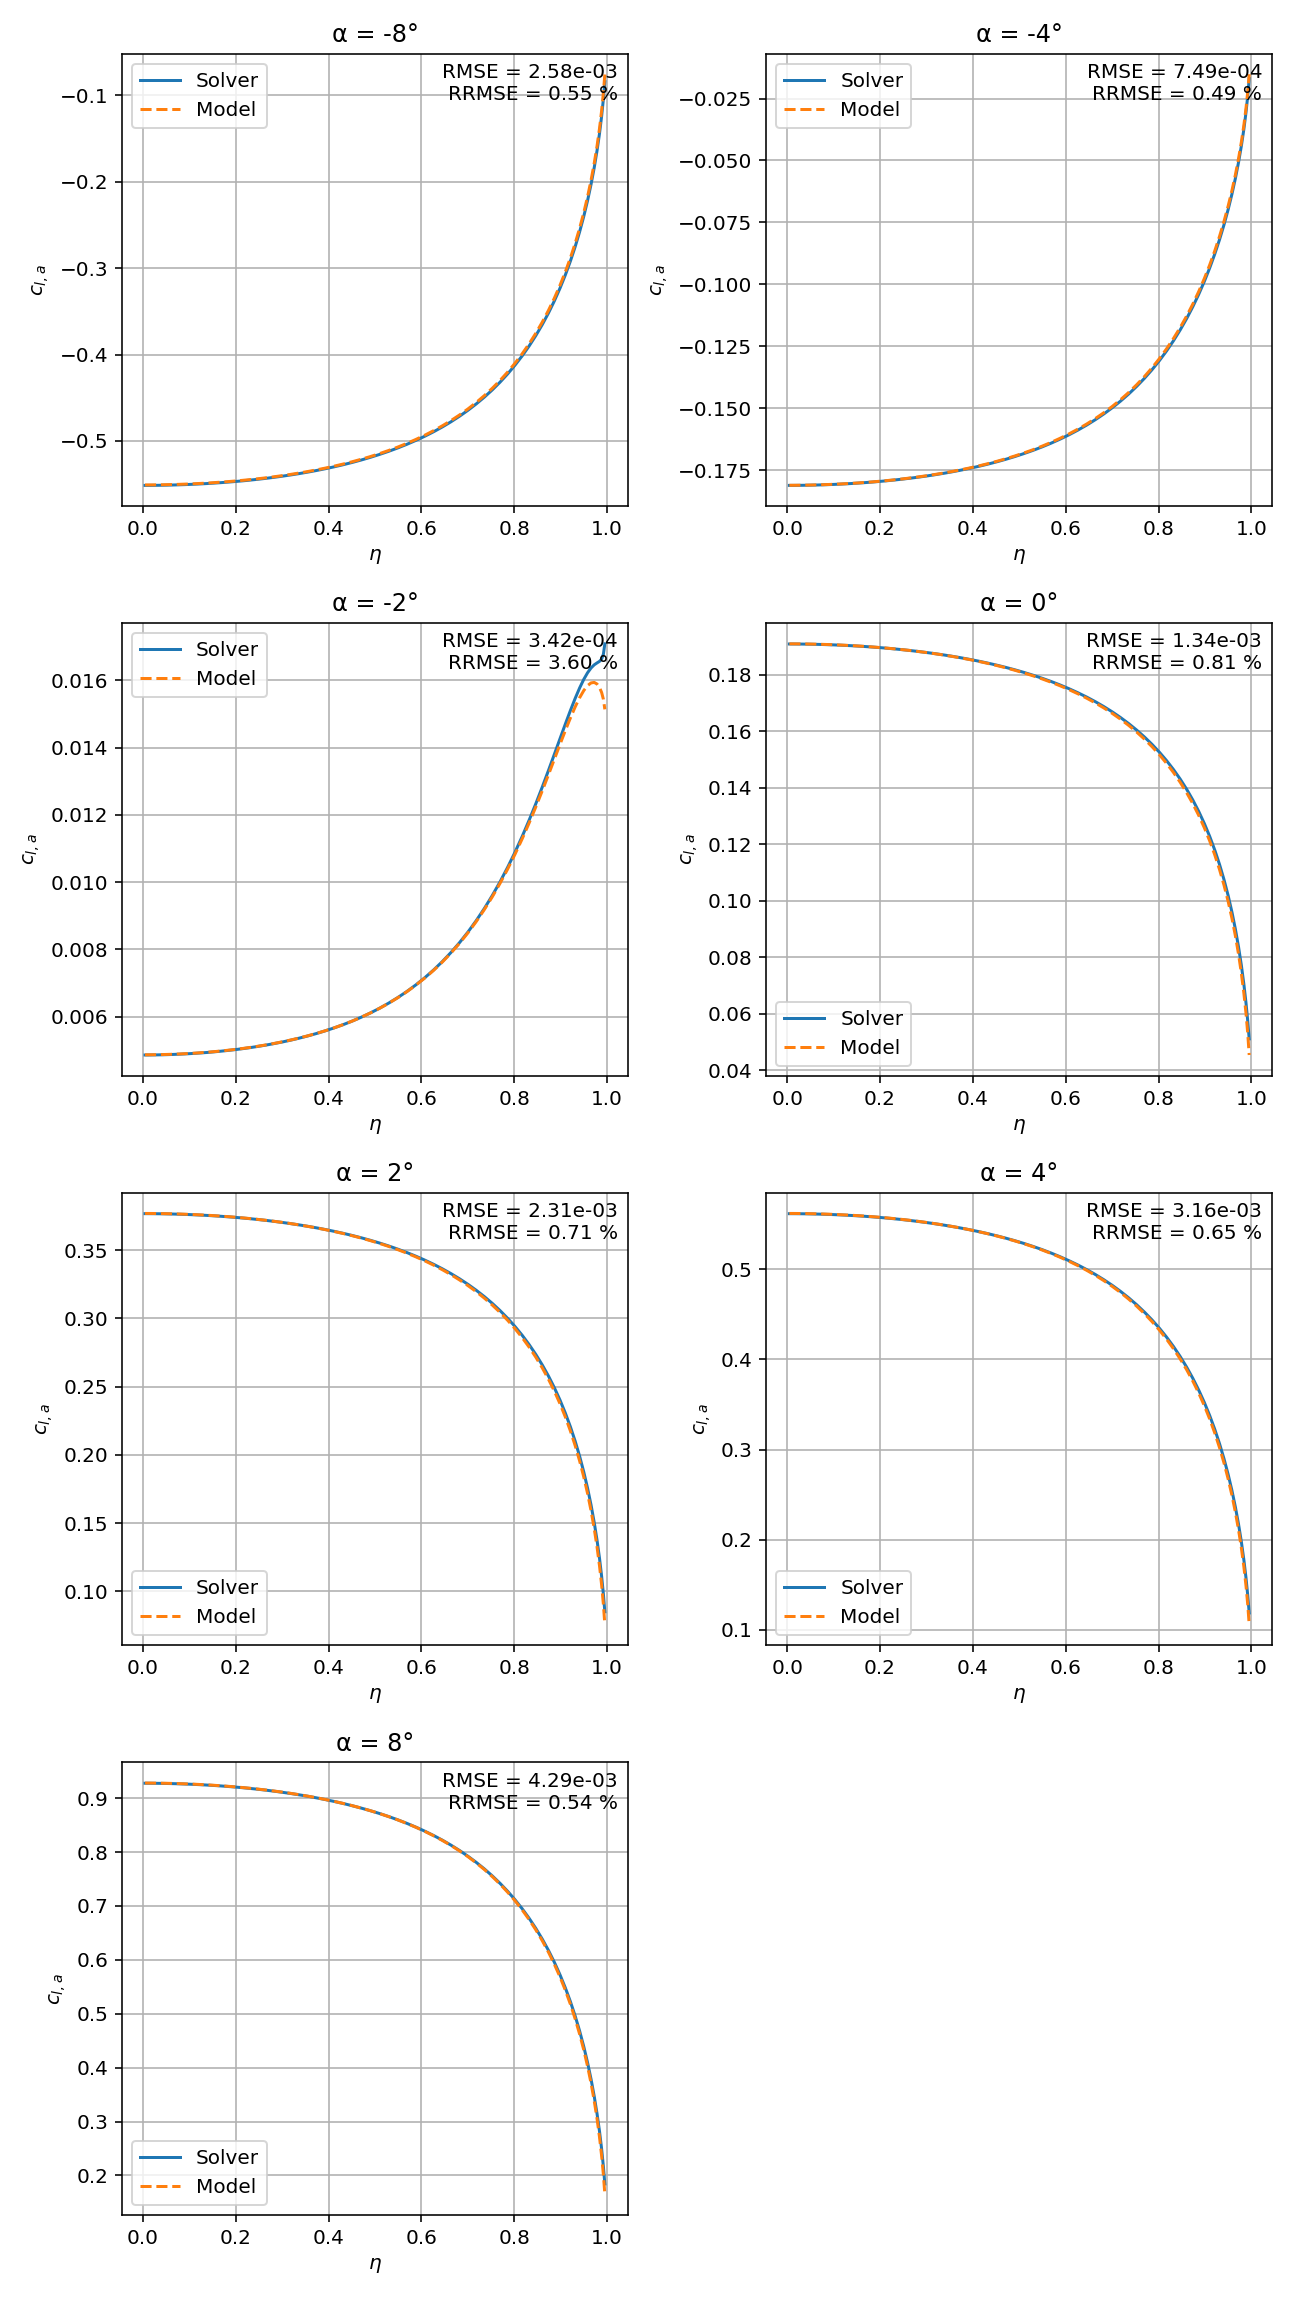

In [54]:
compare_coeff_predict(cl_aero_cam_table, eval_cl_aero_pred_cam, "$c_{l, a}$", [-8, -4, -2, 0, 2, 4, 8])

/tmp/ipykernel_297509/297234456.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


<IPython.core.display.Javascript object>


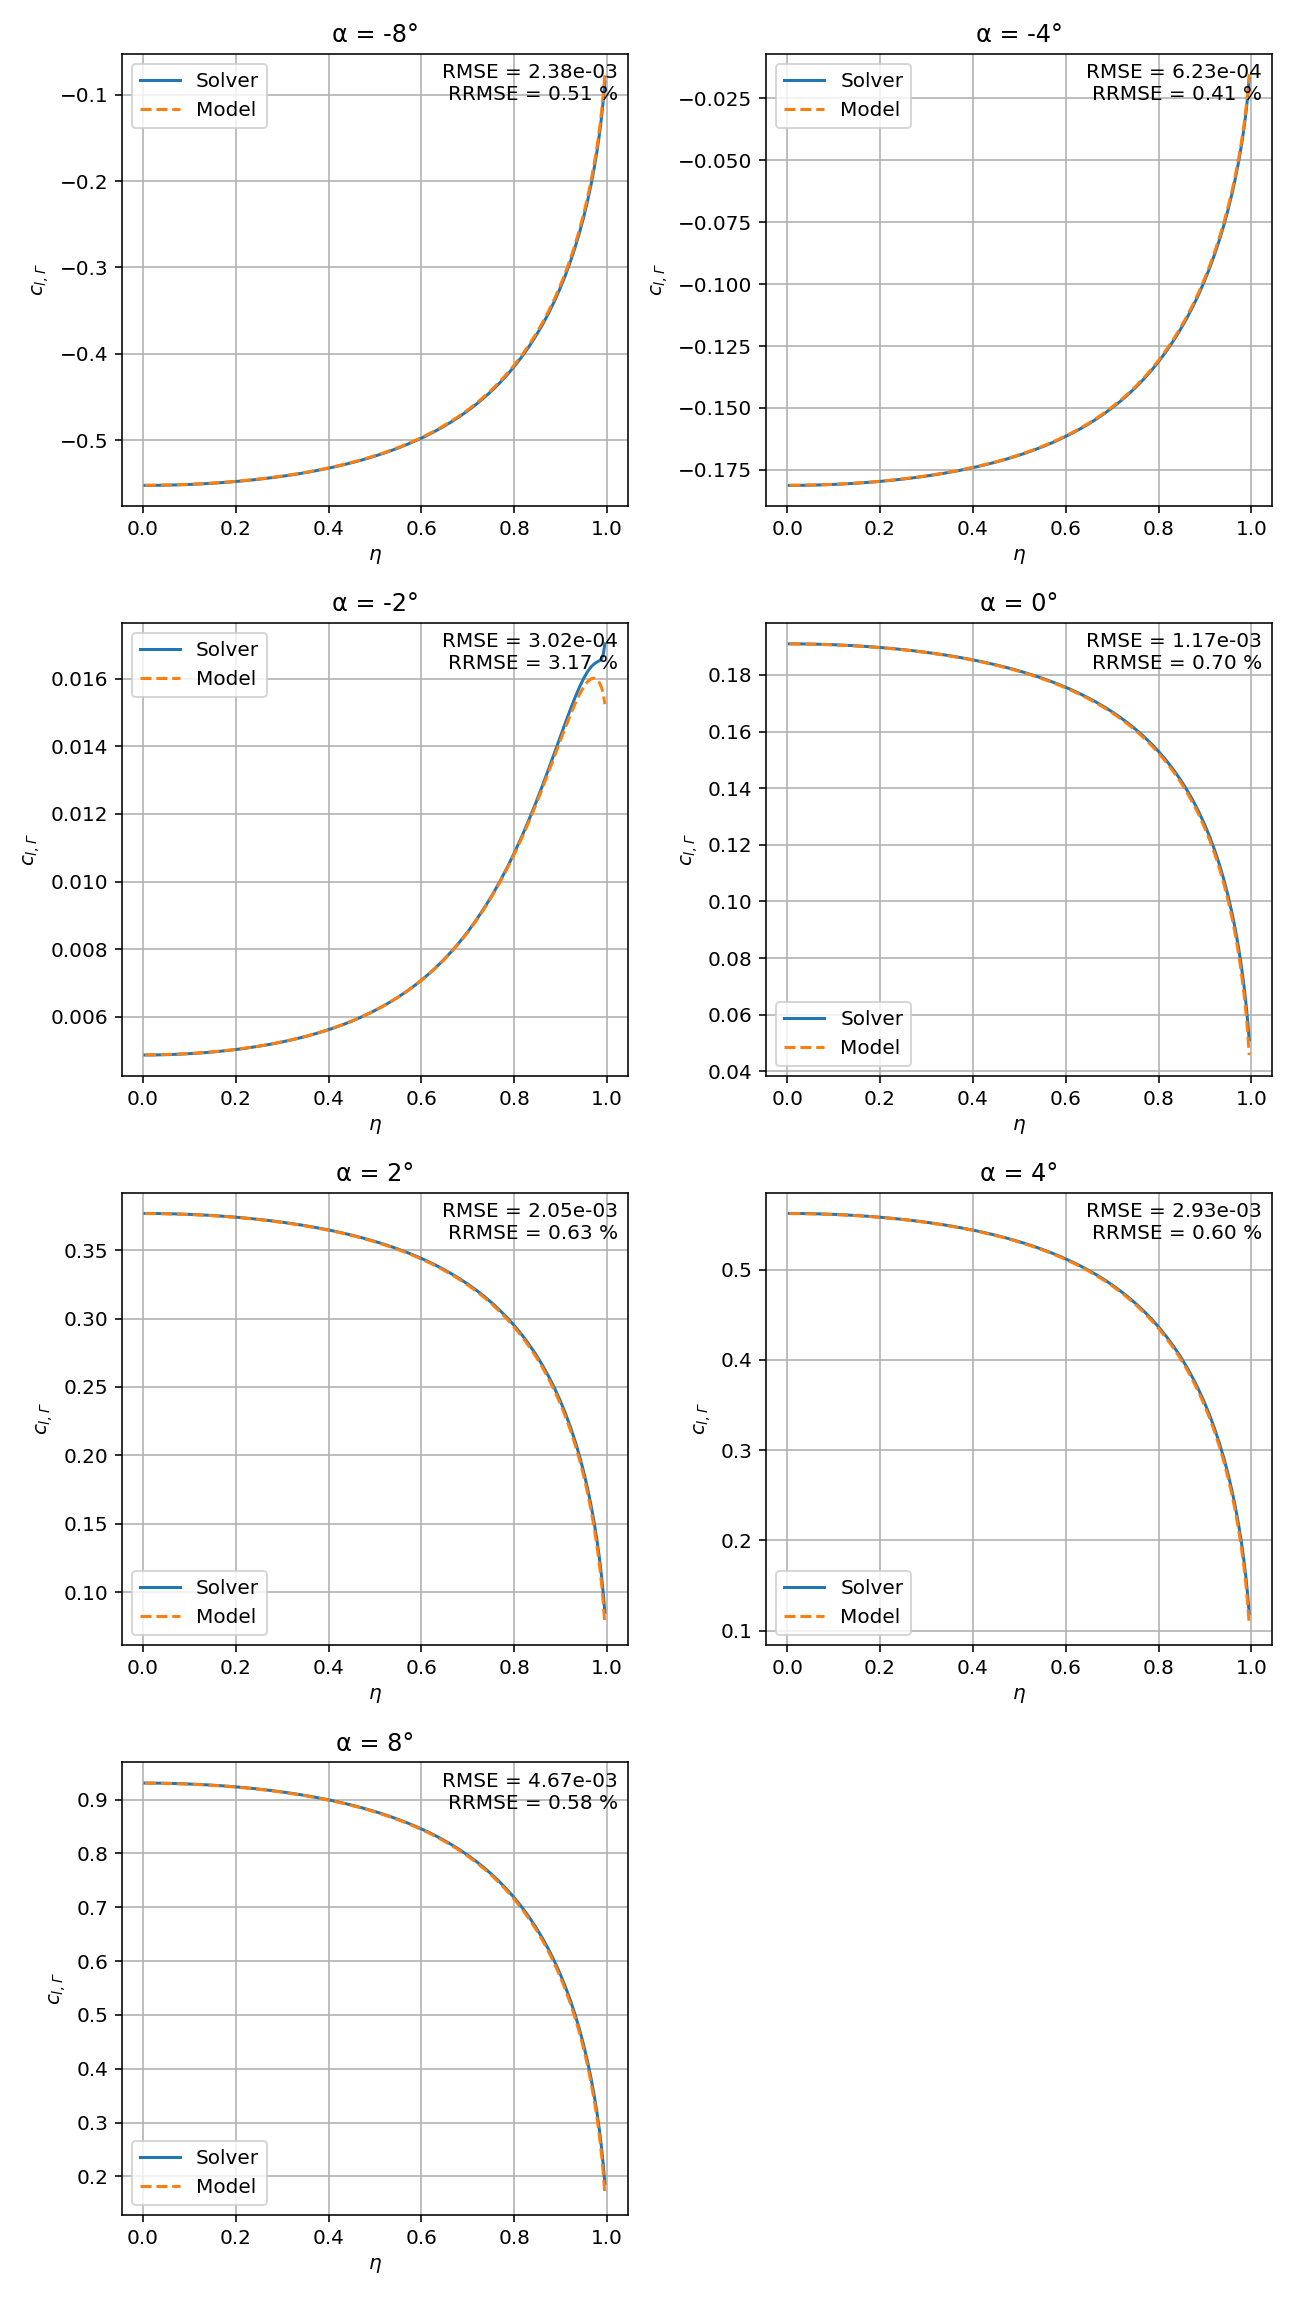

In [56]:
compare_coeff_predict(cl_circ_cam_table, eval_cl_circ_pred_cam, "$c_{l, Г}$", [-8, -4, -2, 0, 2, 4, 8])

### 3.5 Find $\alpha_{mindrag}(\eta)$ by fitting polynomials to $c_{d, i}(\alpha)$ data

In [57]:
def find_min_from_poly(coeffs, x_range):
    """coeffs = np.poly1d-style, highest power first. Return (x_min, y_min)
    among real critical points inside x_range with positive curvature,
    falling back to a bounded search if that fails."""
    poly = np.poly1d(coeffs)
    dpoly = poly.deriv()
    ddpoly = dpoly.deriv()
    roots = dpoly.r
    real_roots = roots[np.abs(roots.imag) < 1e-8].real
    candidates = [x for x in real_roots
                  if x_range[0] <= x <= x_range[1] and ddpoly(x) > 0]
    if candidates:
        x_min = min(candidates, key=lambda x: poly(x))
        return x_min, poly(x_min)
    # fallback: bounded numeric minimization (handles edge minima too)
    res = minimize_scalar(poly, bounds=x_range, method='bounded')
    return res.x, res.fun

In [58]:
R2_THRESHOLD = 0.995   # below this, the polynomial isn't trusted -> spline
records = []
fit_store = {}  # eta -> dict with alpha, cd, method, callable for plotting


for eta, row in cd_aero_cam_table.iterrows():
    cd_vals = row.to_numpy()
    x_range = (alphas.min(), alphas.max())

    # --- try quadratic first (cheapest, most stable) ---
    popt2, _ = curve_fit(poly2, alphas, cd_vals, p0=[1.0, 0.0, cd_vals.min()])
    r2_2 = r_squared(cd_vals, poly2(alphas, *popt2))

    # --- try quartic (captures flat-bottom drag-bucket asymmetry) ---
    popt4, _ = curve_fit(poly4, alphas, cd_vals, p0=[0.0, 0.0, 1.0, 0.0, cd_vals.min()],
                          maxfev=10000)
    r2_4 = r_squared(cd_vals, poly4(alphas, *popt4))

    if r2_4 >= R2_THRESHOLD:
        coeffs = popt4
        alpha_min, cd_min = find_min_from_poly(coeffs, x_range)
        method = 'poly4'
        r2_used = r2_4
    elif r2_2 >= R2_THRESHOLD:
        coeffs = popt2
        alpha_min, cd_min = find_min_from_poly(coeffs, x_range)
        method = 'poly2'
        r2_used = r2_2
    else:
        # --- fall back to a smoothing spline ---
        spline = UnivariateSpline(alphas, cd_vals, k=4, s=len(alphas) * 1e-7)
        res = minimize_scalar(spline, bounds=x_range, method='bounded')
        alpha_min, cd_min = res.x, float(res.fun)
        method = 'spline'
        r2_used = r_squared(cd_vals, spline(alphas))

    records.append(dict(eta=eta, alpha_min_drag=alpha_min, cd_min=cd_min,
                         method=method, r2=r2_used))
    fit_store[eta] = dict(alphas=alphas, cd=cd_vals, method=method,
                               popt2=popt2, popt4=popt4)

results = pd.DataFrame.from_records(records)

In [59]:
print(results['method'].value_counts())
# print(results.to_string(index=False))

method
poly4    74
Name: count, dtype: int64


In [60]:
alpha_min_drag = results["alpha_min_drag"].to_numpy()
cd_cam_min = results["cd_min"].to_numpy()

<IPython.core.display.Javascript object>


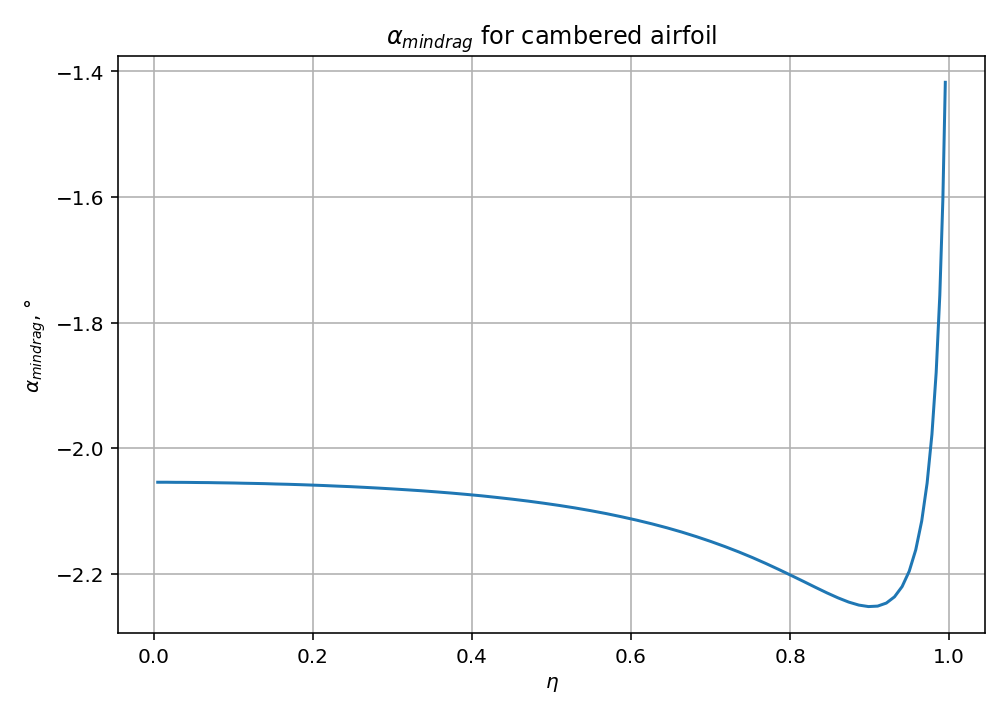

In [61]:
# Plot
fig = plt.figure(figsize=(7, 5))

ax = fig.add_subplot(111)
ax.set_title(r"$\alpha_{mindrag}$ for cambered airfoil")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\alpha_{mindrag}$, °")
ax.plot(etas, alpha_min_drag)

plt.grid()
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


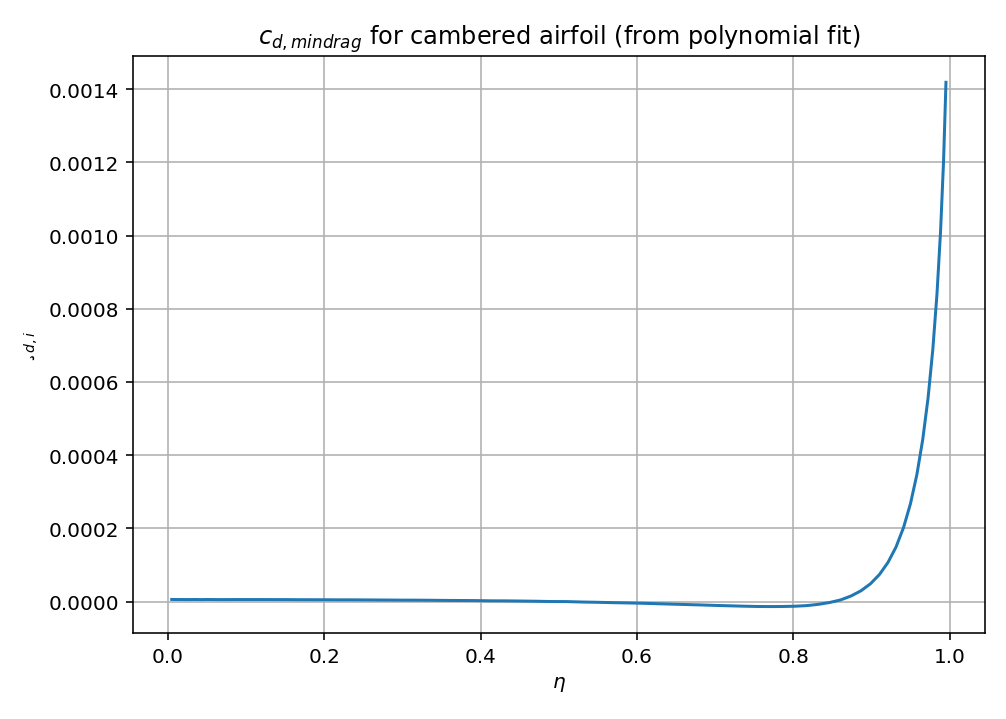

In [62]:
# Plot
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.set_title(r"$c_{d, {mindrag}}$ for cambered airfoil (from polynomial fit)")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\c_{d, i}$")
ax.plot(etas, cd_cam_min)

plt.grid()
plt.tight_layout()
plt.show()

### 3.6 Normalize Cd for cambered airfoil

In [63]:
cd_aero_cam_norm_table = pd.DataFrame(index=cd_aero_cam_table.index)

for col in alpha_cols:
    alpha_deg = alpha_values[col]     
    if alpha_deg == int(alpha_zero_lift_cam):
        continue
      
    cd_cam = cd_aero_cam_table[col].to_numpy(dtype=float)
    sin_alpha = np.sin(np.radians(alpha_deg))
    sin_alpha_md = np.sin(np.radians(alpha_min_drag))
    cos_alpha_cam = np.cos(np.radians(alpha_deg - alpha_min_drag)) 
    
    cd_aero_cam_norm_table[col] = (cd_cam - cd_cam_min) / (cos_alpha_cam * (sin_alpha - sin_alpha_md)**2)

<IPython.core.display.Javascript object>


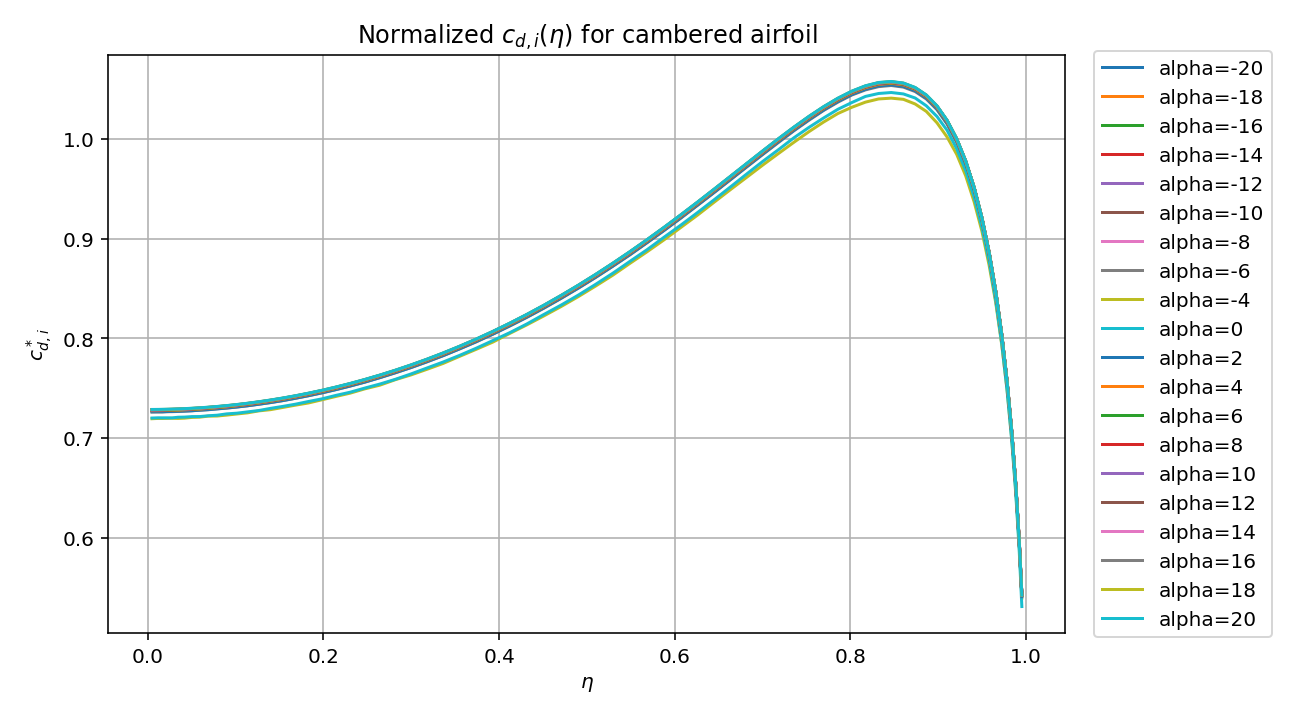

In [64]:
ax = cd_aero_cam_norm_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$c_{d,i}^*$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"Normalized $c_{d,i}(\eta)$ for cambered airfoil")
ax.figure.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


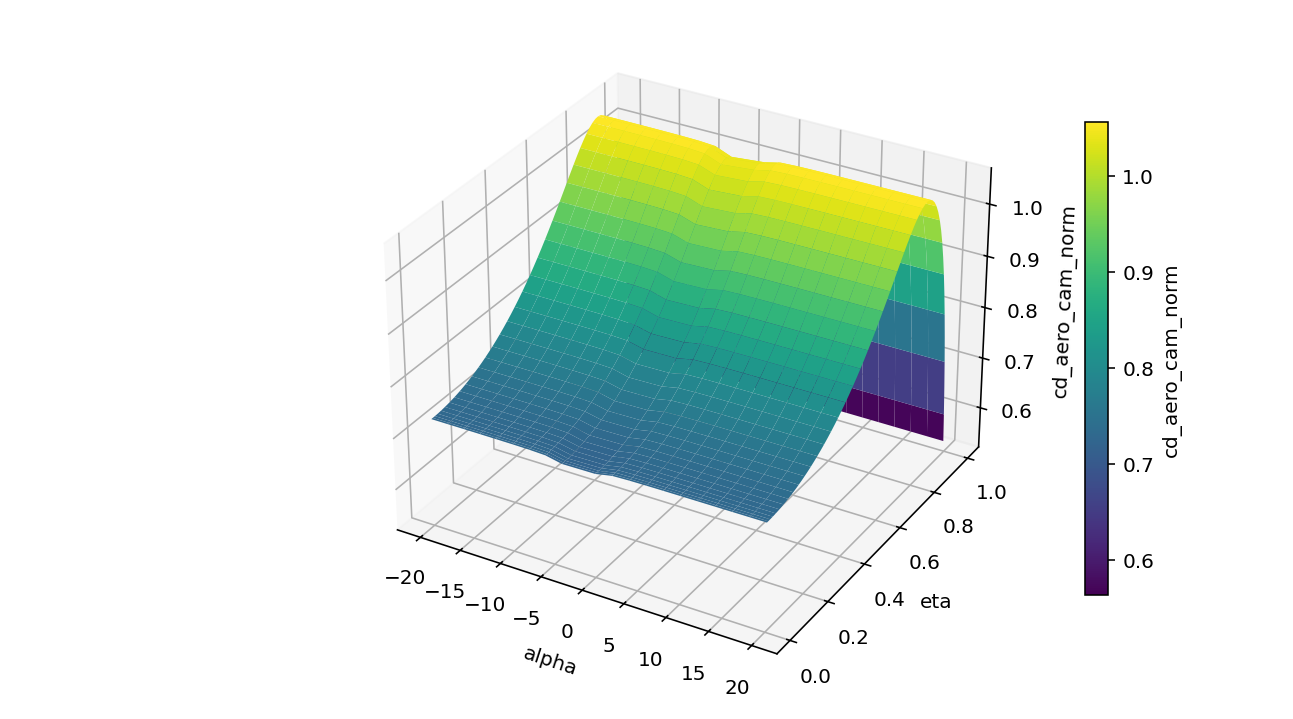

In [65]:
plot_df3d(cd_aero_cam_norm_table, zlabel="cd_aero_cam_norm")

### 3.7 Evaluate Cd normalization errors

#### Compare Cd_sym_norm and Cd_cam_norm

In [66]:
## pick single curve from symmetric airfoil normalized results
cd_norm_sym = cd_aero_sym_norm_table[f"alpha={alpha_ref_sym}"].to_numpy() 
cd_norm_cam = cd_aero_cam_norm_table[f"alpha={alpha_ref_cam}"].to_numpy()

cd_norm_diff = cd_norm_sym - cd_norm_cam

In [67]:
cd_norm_diff

array([ 1.17194366e-03,  1.16835534e-03,  1.15986666e-03,  1.16165620e-03,
        1.17592997e-03,  1.19232369e-03,  1.15413600e-03,  1.15836211e-03,
        1.14956118e-03,  1.17046725e-03,  1.19295810e-03,  1.19967025e-03,
        1.20307612e-03,  1.20620592e-03,  1.19024699e-03,  1.21944973e-03,
        1.20408897e-03,  1.18612969e-03,  1.19047502e-03,  1.23868209e-03,
        1.26084564e-03,  1.24359020e-03,  1.27448379e-03,  1.29419011e-03,
        1.31040085e-03,  1.30729932e-03,  1.28531914e-03,  1.30914093e-03,
        1.30389996e-03,  1.35732645e-03,  1.35573023e-03,  1.36629500e-03,
        1.35415772e-03,  1.35963264e-03,  1.39902477e-03,  1.40952072e-03,
        1.39987895e-03,  1.40110747e-03,  1.40502875e-03,  1.39234454e-03,
        1.43369230e-03,  1.36644175e-03,  1.35760758e-03,  1.31964270e-03,
        1.27529835e-03,  1.18324291e-03,  1.15981785e-03,  1.05825475e-03,
        9.56753483e-04,  8.30085777e-04,  7.28957764e-04,  6.53219051e-04,
        5.43175066e-04,  

<IPython.core.display.Javascript object>


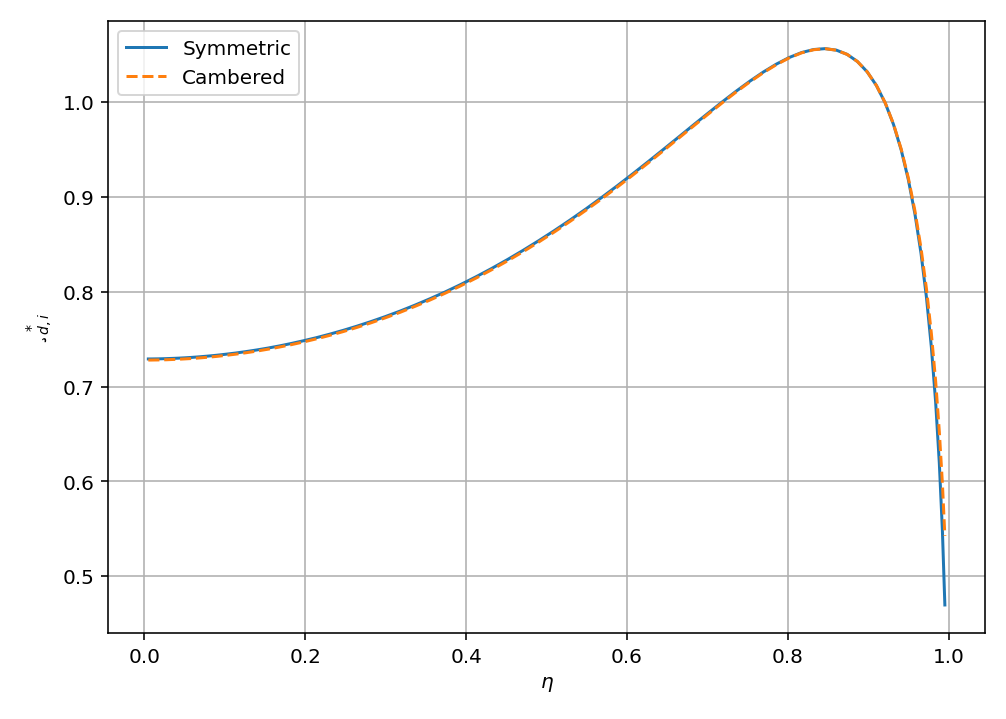

In [68]:
# Plot Cd norm
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)

ax.plot(etas, cd_norm_sym, label="Symmetric")
ax.plot(etas, cd_norm_cam, "--", label="Cambered")

ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$\c_{d, i}^*$")
ax.legend()

plt.grid()
plt.tight_layout()
plt.show()

#### Evaluate absolute Cd prediction errors

In [69]:
cd_aero_sym_pred_error_table = pd.DataFrame(index=cd_aero_sym_table.index)
cd_aero_cam_pred_error_table = pd.DataFrame(index=cd_aero_cam_table.index)

for col in alpha_cols:
    alpha_deg = alpha_values[col]
         
    cd_sym = cd_aero_sym_table[col].to_numpy(dtype=float)
    cd_cam = cd_aero_cam_table[col].to_numpy(dtype=float)
          
    sin_alpha = np.sin(np.radians(alpha_deg))
    cos_alpha = np.cos(np.radians(alpha_deg))

    sin_alpha_cam = np.sin(np.radians(alpha_deg - alpha_min_drag))
    cos_alpha_cam = np.cos(np.radians(alpha_deg - alpha_min_drag))
    
    sin_alpha_md = np.sin(np.radians(alpha_min_drag))
    cos_alpha_md = np.cos(np.radians(alpha_min_drag))
    
    cd_sym_pred = cd_norm_sym * cos_alpha * sin_alpha**2
    cd_cam_pred = cd_cam_min + cd_norm_cam * cos_alpha_cam * (sin_alpha - sin_alpha_md)**2

    cd_aero_sym_pred_error_table[col] = (cd_sym - cd_sym_pred)
    cd_aero_cam_pred_error_table[col] = (cd_cam - cd_cam_pred)

<IPython.core.display.Javascript object>


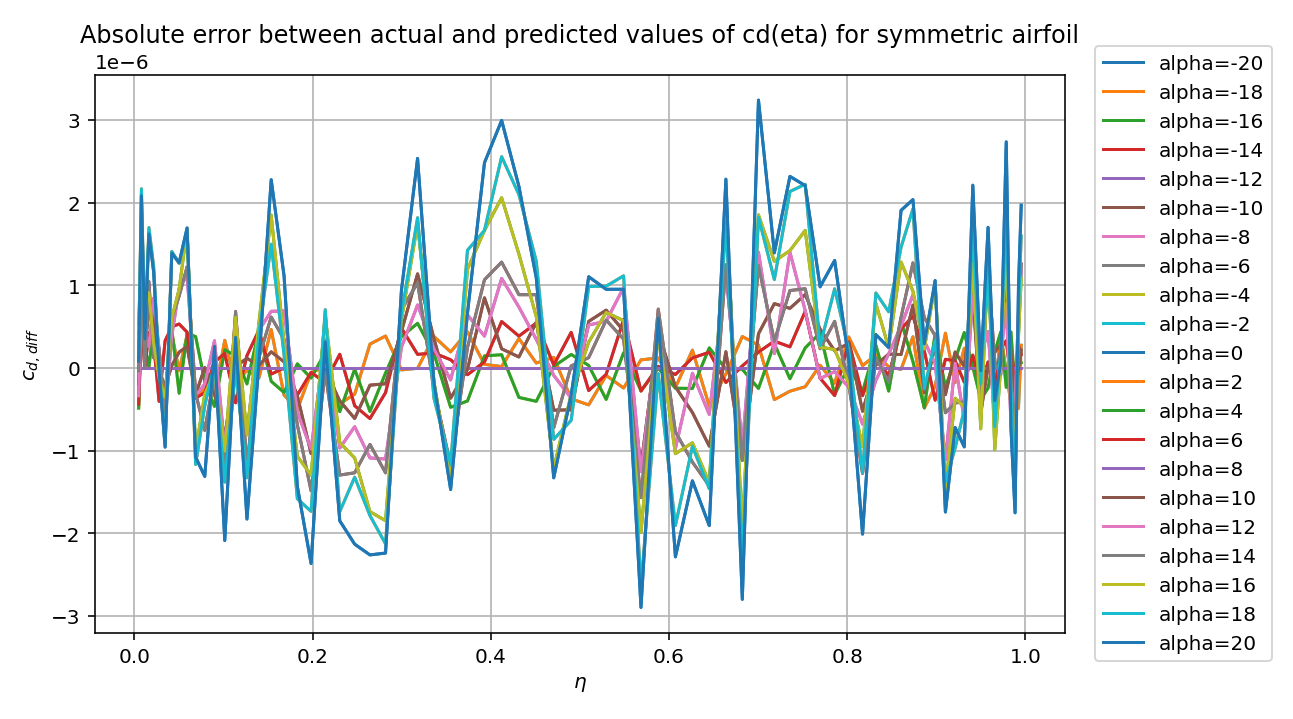

In [70]:
ax = cd_aero_sym_pred_error_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$c_{d,diff}$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"Absolute error between actual and predicted values of cd(eta) for symmetric airfoil")
ax.figure.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


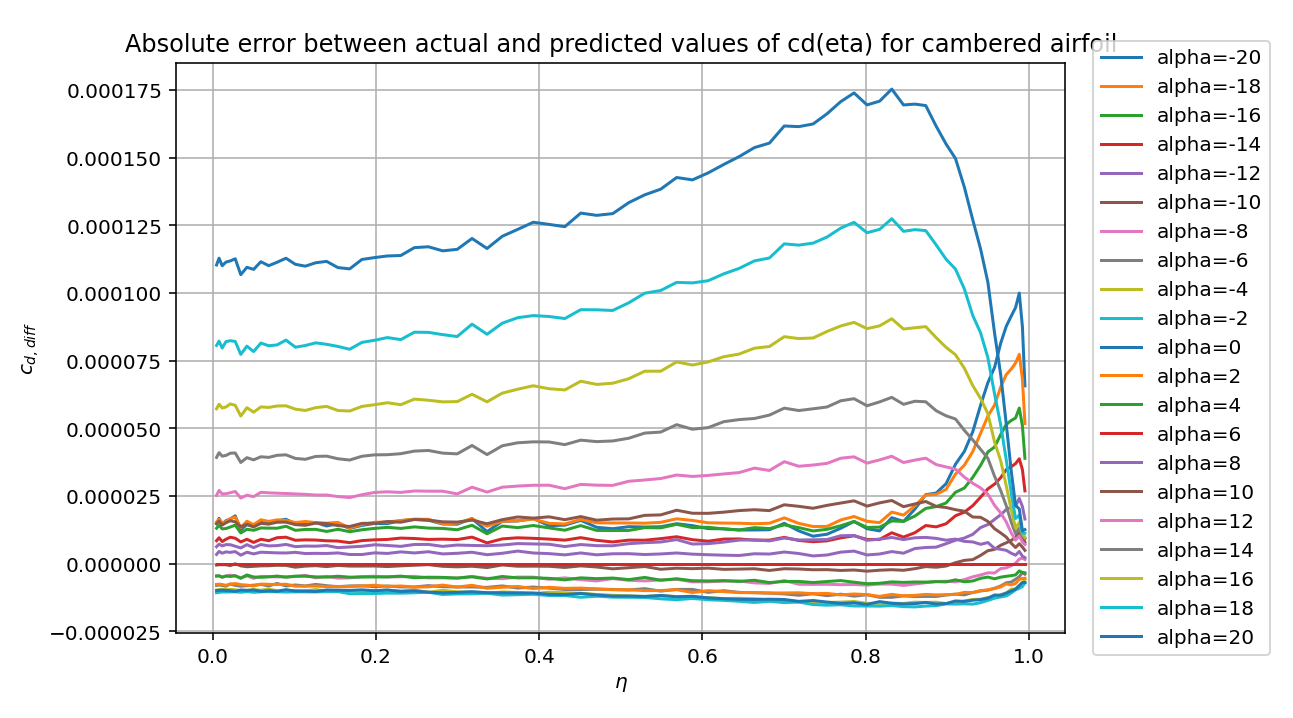

In [71]:
ax = cd_aero_cam_pred_error_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$c_{d,diff}$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"Absolute error between actual and predicted values of cd(eta) for cambered airfoil")
ax.figure.tight_layout()
plt.show()

#### Compare actual vs predicted Cd curves

In [72]:
def eval_cd_pred_sym(alpha_deg):
    sin_alpha = np.sin(np.radians(alpha_deg))
    cos_alpha = np.cos(np.radians(alpha_deg))
    
    cd_pred = cd_norm_sym * cos_alpha * sin_alpha**2
    
    return np.array(cd_pred) 

In [73]:
def eval_cd_pred_cam(alpha_deg):
    sin_alpha = np.sin(np.radians(alpha_deg))
    cos_alpha = np.cos(np.radians(alpha_deg))
    cos_alpha_cam = np.cos(np.radians(alpha_deg - alpha_min_drag))
    sin_alpha_md = np.sin(np.radians(alpha_min_drag))
    
    cd_pred = cd_cam_min + cd_norm_sym * cos_alpha_cam * (sin_alpha - sin_alpha_md)**2
    
    return np.array(cd_pred)

<IPython.core.display.Javascript object>


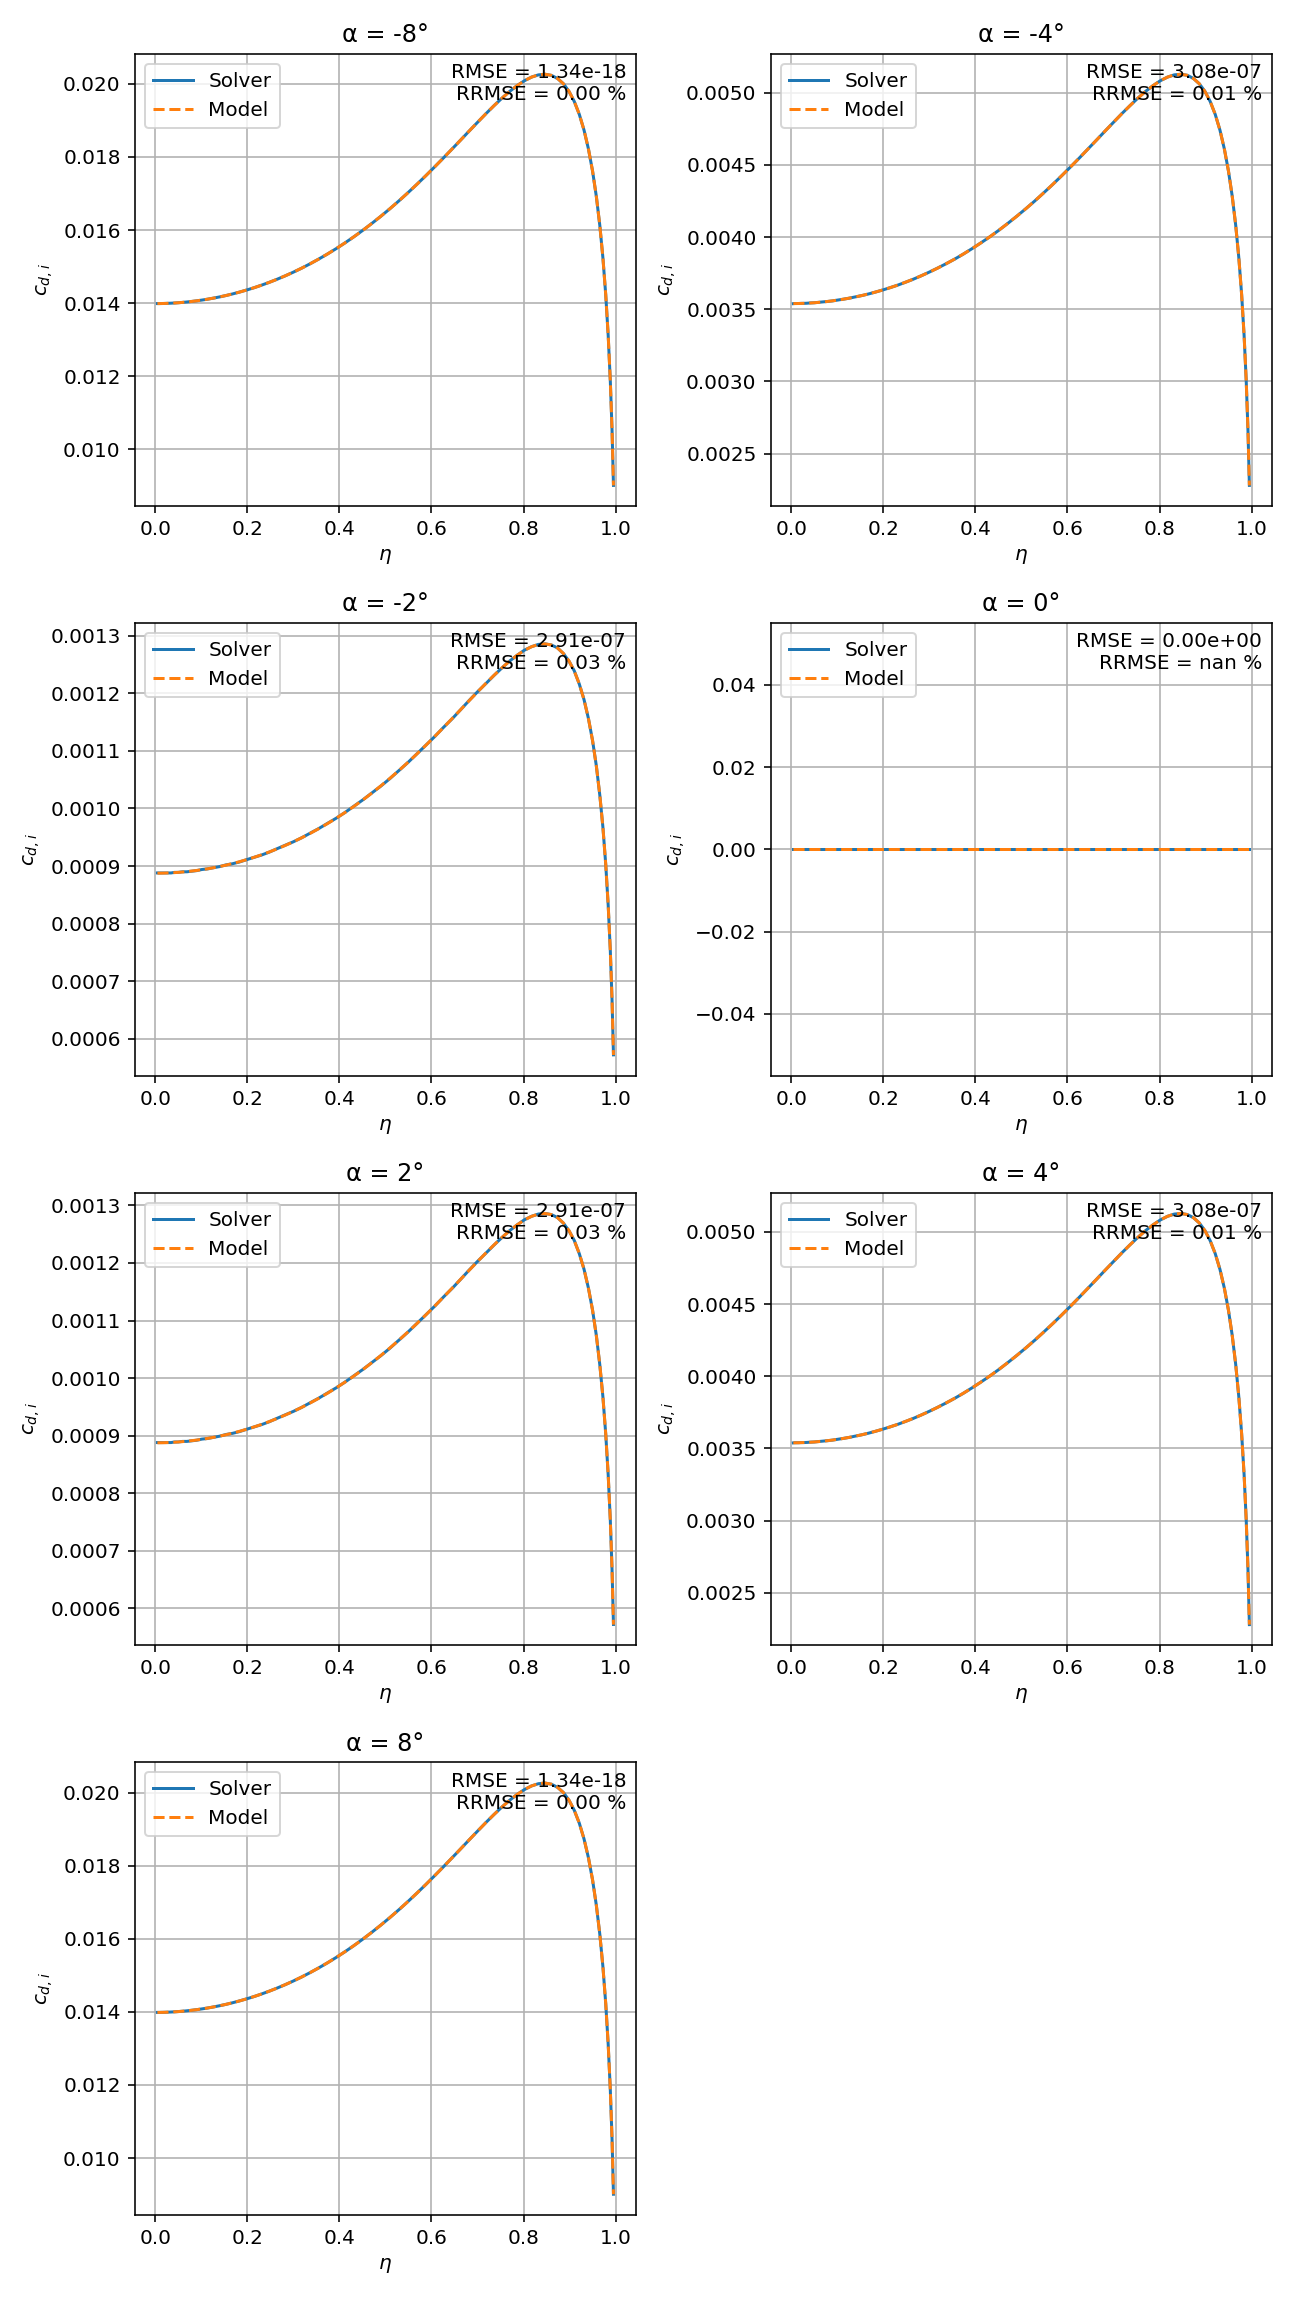

/tmp/ipykernel_297509/297234456.py:21: RuntimeWarning: invalid value encountered in scalar divide
  rrmse = rmse / np.sqrt(np.mean(coeff**2))


In [74]:
compare_coeff_predict(cd_aero_sym_table, eval_cd_pred_sym, "$c_{d, i}$", [-8, -4, -2, 0, 2, 4, 8])

<IPython.core.display.Javascript object>


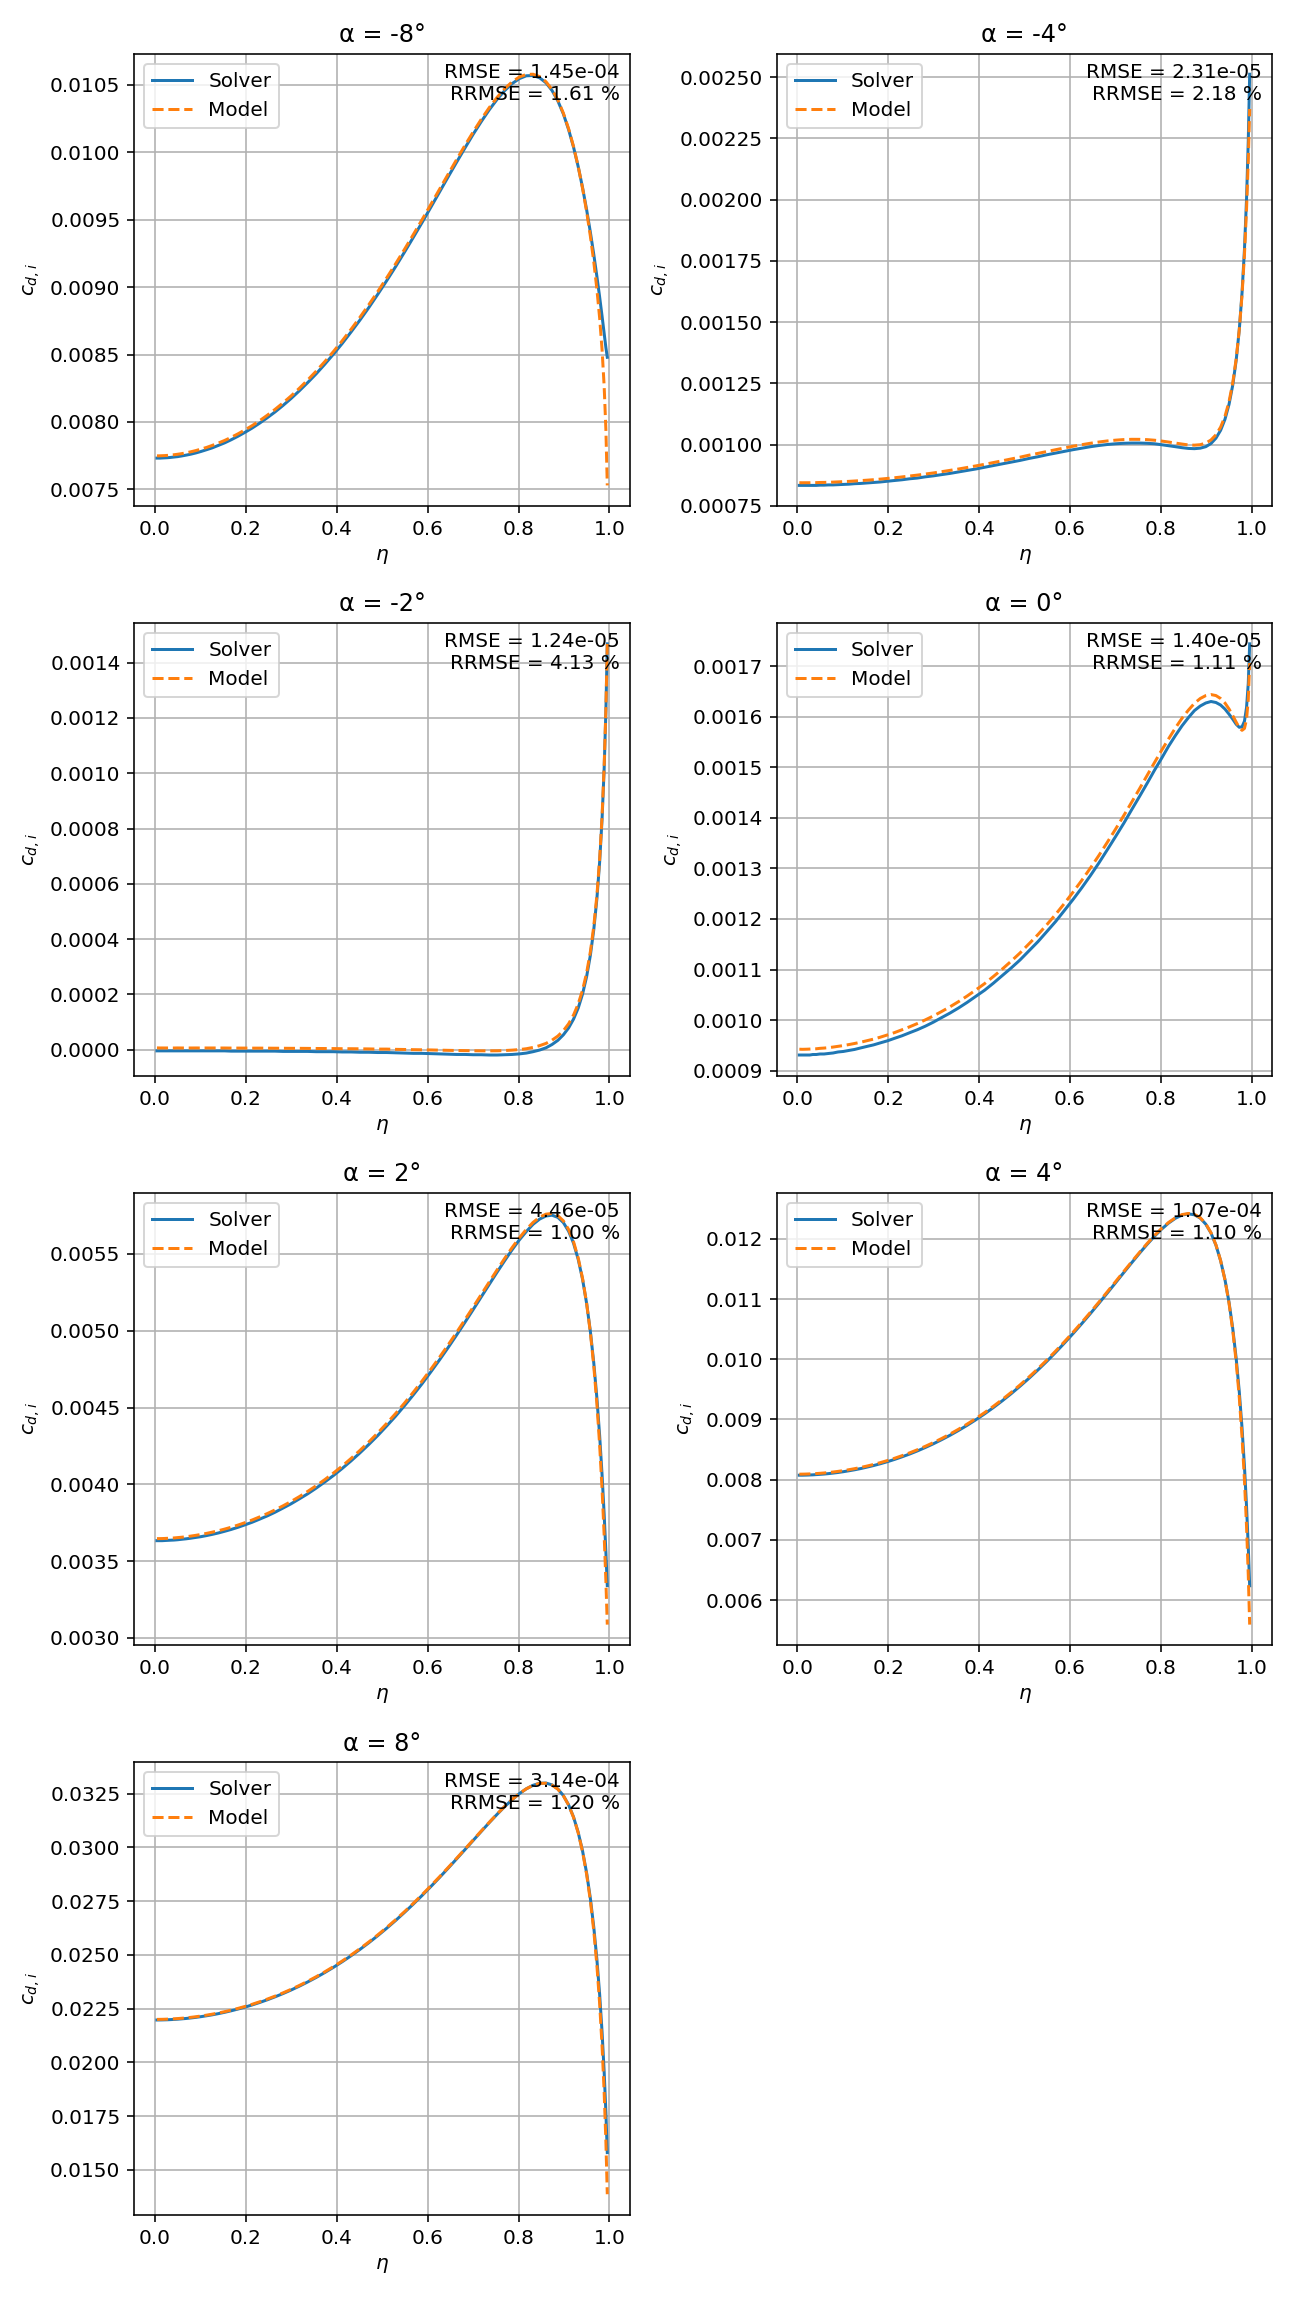

In [75]:
compare_coeff_predict(cd_aero_cam_table, eval_cd_pred_cam, "$c_{d, i}$", [-8, -4, -2, 0, 2, 4, 8])

### 3.8 Simplified Normalized Cd_cam model, where Cd_min is set to zero

#### Find alpha_min_drag from the model

In [78]:
def find_alpha_m():
    alpha_m = []
    residuals = []
    sin_alphas = np.sin(np.radians(alphas))

    eta_i = 0
    for eta, row in cd_aero_cam_table.iterrows():
        cd_vals = row.to_numpy()

        def residual(x):
            alpha_m = x[0]

            cos_alpha_cam_m = np.cos(np.radians(alphas - alpha_m))
            sin_alpha_m = np.sin(np.radians(alpha_m))

            cd_model = (
                cd_norm_sym[eta_i]
                * (sin_alphas - sin_alpha_m)**2
                * cos_alpha_cam_m
            )

            return cd_model - cd_vals

        result = least_squares(
            residual,
            x0=[0.0]
        )

        alpha_m.append(result.x[0])
        residuals.append(residual(result.x))
        eta_i += 1
        
    return np.array(alpha_m), np.array(residuals)

In [79]:
alpha_m, residuals = find_alpha_m()
alpha_m

array([-2.05395866, -2.05406217, -2.05401065, -2.05404124, -2.05408207,
       -2.05407088, -2.05409925, -2.05424699, -2.05436062, -2.05448776,
       -2.05446327, -2.05469037, -2.05491577, -2.05505769, -2.0554459 ,
       -2.05570383, -2.05614388, -2.05665669, -2.05710069, -2.05760235,
       -2.05822214, -2.0590735 , -2.05981843, -2.06072109, -2.06173913,
       -2.06290727, -2.06428361, -2.06578233, -2.0672563 , -2.06894808,
       -2.0709541 , -2.07308456, -2.07542654, -2.0779797 , -2.08073544,
       -2.08372771, -2.08711096, -2.09081174, -2.09483337, -2.09919604,
       -2.10382811, -2.10909588, -2.11461618, -2.12067964, -2.12717291,
       -2.13431729, -2.14168469, -2.14983945, -2.15827074, -2.1672364 ,
       -2.1765539 , -2.18618663, -2.19609978, -2.2060836 , -2.21597217,
       -2.22569249, -2.23477264, -2.24294665, -2.24981851, -2.25484574,
       -2.257586  , -2.2572319 , -2.25328761, -2.24484065, -2.23113159,
       -2.21102902, -2.18398503, -2.14885729, -2.10530567, -2.05

In [80]:
alpha_min_drag

array([-2.05431556, -2.05433496, -2.05432627, -2.05432153, -2.05440939,
       -2.05449432, -2.05450184, -2.05457452, -2.05470153, -2.05482411,
       -2.05491384, -2.05515151, -2.05534153, -2.05556622, -2.05592242,
       -2.05622321, -2.05656435, -2.05713008, -2.05756774, -2.05814848,
       -2.05883655, -2.05958781, -2.06049807, -2.06135513, -2.06243271,
       -2.06360953, -2.06491755, -2.066352  , -2.06787707, -2.06965721,
       -2.07155387, -2.07368359, -2.07595912, -2.07858881, -2.08135929,
       -2.08437582, -2.08772315, -2.09130638, -2.09522635, -2.09952638,
       -2.10418221, -2.10929006, -2.1147212 , -2.12057965, -2.12687746,
       -2.13366491, -2.14096698, -2.14868776, -2.15683374, -2.16539588,
       -2.17436155, -2.18371397, -2.19328841, -2.20295001, -2.21245149,
       -2.22181029, -2.23060369, -2.23850646, -2.2451741 , -2.24996987,
       -2.2523436 , -2.25159559, -2.24676175, -2.23683597, -2.22047626,
       -2.19610386, -2.16201996, -2.11606059, -2.05567153, -1.97

In [81]:
residuals

array([[ 8.61308725e-05,  6.48730633e-05,  4.82526950e-05, ...,
         4.22024784e-05,  4.14161330e-05,  3.56482756e-05],
       [ 8.34019808e-05,  6.32084798e-05,  4.66581825e-05, ...,
         4.09426111e-05,  4.02153668e-05,  3.34997607e-05],
       [ 8.54145049e-05,  6.42802111e-05,  4.78636614e-05, ...,
         4.13833309e-05,  4.16419864e-05,  3.49751787e-05],
       ...,
       [-5.20967963e-03, -4.50941398e-03, -3.85230751e-03, ...,
        -2.96928679e-03, -3.52789186e-03, -4.13448366e-03],
       [-7.31950062e-03, -6.29879230e-03, -5.34091552e-03, ...,
        -4.18832131e-03, -5.02145303e-03, -5.92642433e-03],
       [-1.02963344e-02, -8.81465131e-03, -7.42411290e-03, ...,
        -5.89909978e-03, -7.13351387e-03, -8.47196275e-03]],
      shape=(74, 21))

#### Evaluate Cd_norm and Prediction error for cambered airfoil

In [82]:
cd_aero_cam_norm_nodrag_table = pd.DataFrame(index=cd_aero_cam_table.index)
cd_aero_cam_norm_nodrag_error_table = pd.DataFrame(index=cd_aero_cam_table.index)

for col in alpha_cols:
    alpha_deg = alpha_values[col]
    if alpha_deg == int(alpha_zero_lift_cam): ## skip alpha values close to alpha zero lift
        continue

    cd_cam = cd_aero_cam_table[col].to_numpy(dtype=float)
    
    sin_alpha = np.sin(np.radians(alpha_deg))
    cos_alpha = np.cos(np.radians(alpha_deg))

    sin_alpha_cam_md = np.sin(np.radians(alpha_deg - alpha_m))
    cos_alpha_cam_md = np.cos(np.radians(alpha_deg - alpha_m))
    
    sin_alpha_md = np.sin(np.radians(alpha_m))
    cos_alpha_md = np.cos(np.radians(alpha_m))
    
#     sin_alpha_cam_md = np.sin(np.radians(alpha_deg - alpha_min_drag))
#     cos_alpha_cam_md = np.cos(np.radians(alpha_deg - alpha_min_drag))
    
#     sin_alpha_md = np.sin(np.radians(alpha_min_drag))
#     cos_alpha_md = np.cos(np.radians(alpha_min_drag))
    
    sign = np.sign(sin_alpha - sin_alpha_md)
    
    cd_aero_cam_norm_nodrag = cd_cam / (cos_alpha_cam_md * (sin_alpha - sin_alpha_md)**2)
    
    cd_aero_cam_norm_nodrag_table[col] = cd_aero_cam_norm_nodrag
    cd_aero_cam_norm_nodrag_error_table[col] = cd_cam - cd_norm_sym * cos_alpha_cam_md * (sin_alpha - sin_alpha_md)**2

<IPython.core.display.Javascript object>


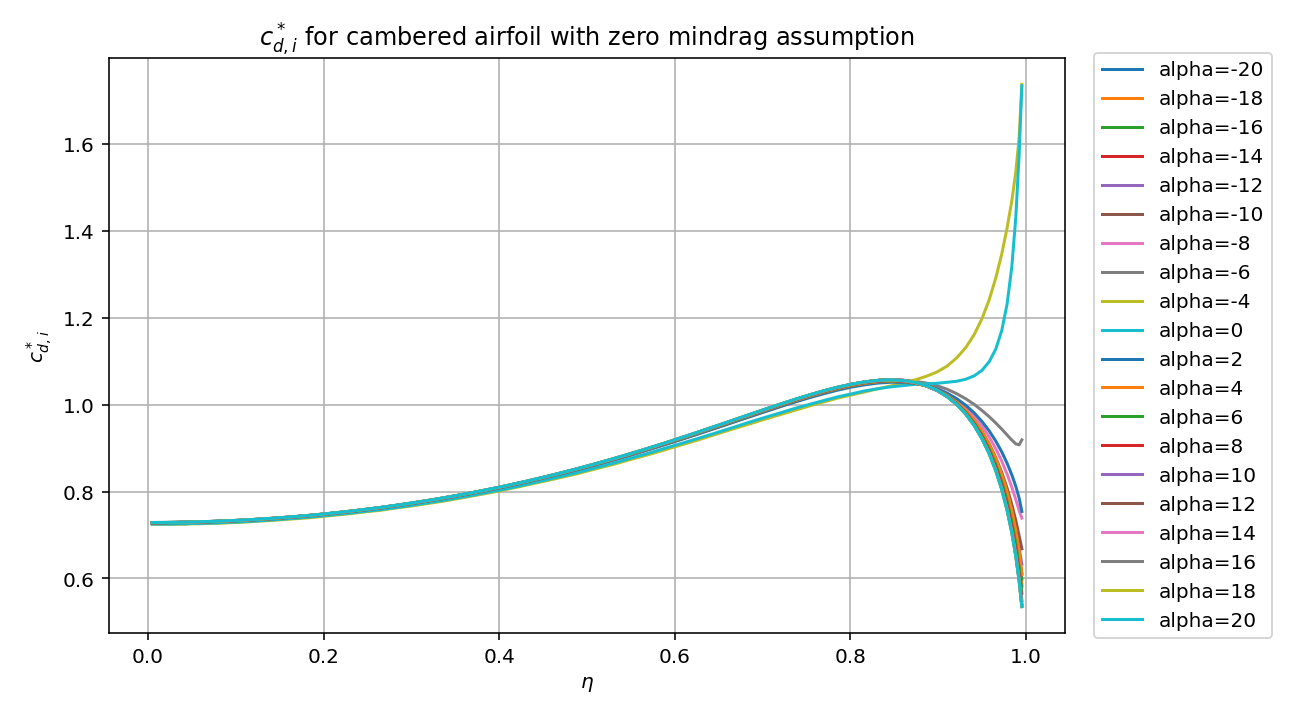

In [83]:
ax = cd_aero_cam_norm_nodrag_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$c_{d,i}^*$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"$c_{d, i}^*$ for cambered airfoil with zero mindrag assumption")
ax.figure.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


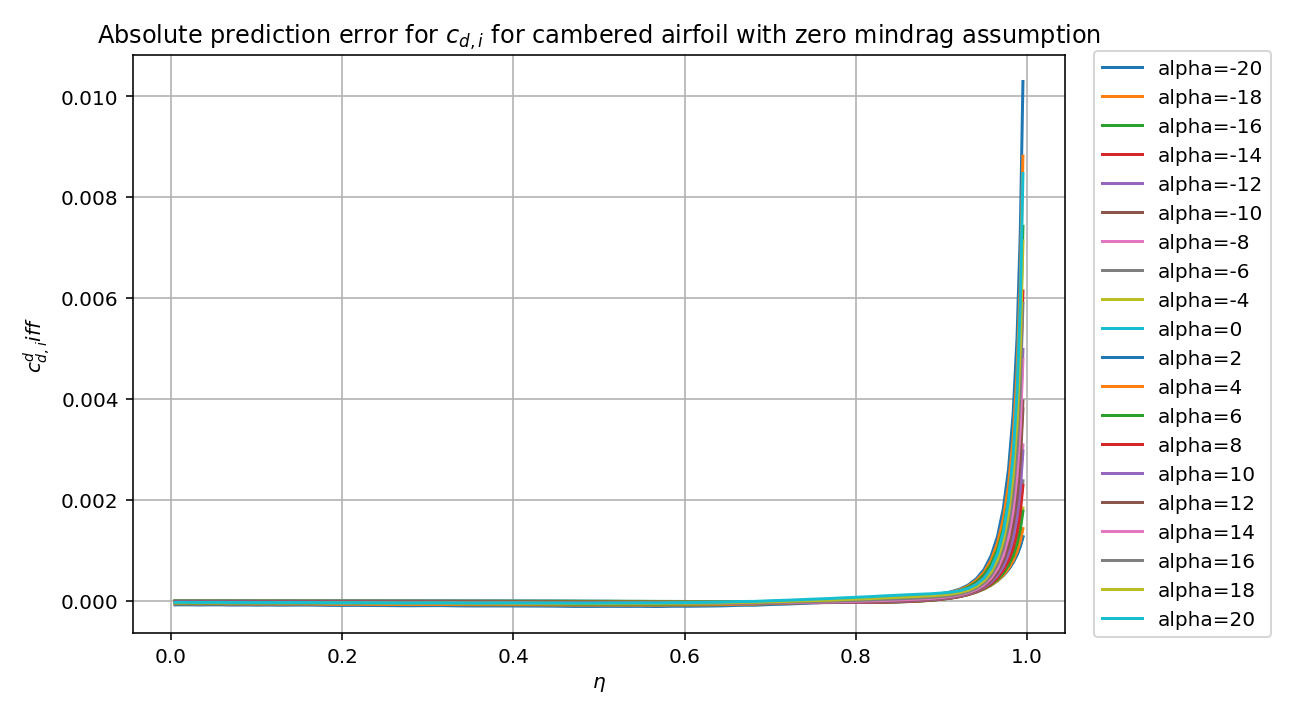

In [84]:
ax = cd_aero_cam_norm_nodrag_error_table.plot(figsize=(9, 5), xlabel=r"$\eta$", ylabel=r"$c_{d,i}^diff$", grid=True)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.set_title(r"Absolute prediction error for $c_{d, i}$ for cambered airfoil with zero mindrag assumption")
ax.figure.tight_layout()
plt.show()

#### Compare actual vs predicted Cd curves

In [85]:
def eval_cd_pred_nomindrag_cam(alpha_deg):
    sin_alpha = np.sin(np.radians(alpha_deg))
    cos_alpha = np.cos(np.radians(alpha_deg))
    cos_alpha_cam = np.cos(np.radians(alpha_deg - alpha_m))
    sin_alpha_md = np.sin(np.radians(alpha_m))
    
#     cos_alpha_cam = np.cos(np.radians(alpha_deg - alpha_min_drag))
#     sin_alpha_md = np.sin(np.radians(alpha_min_drag))
    
    cd_pred = cd_norm_sym * cos_alpha_cam * (sin_alpha - sin_alpha_md)**2
    
    return np.array(cd_pred)

<IPython.core.display.Javascript object>


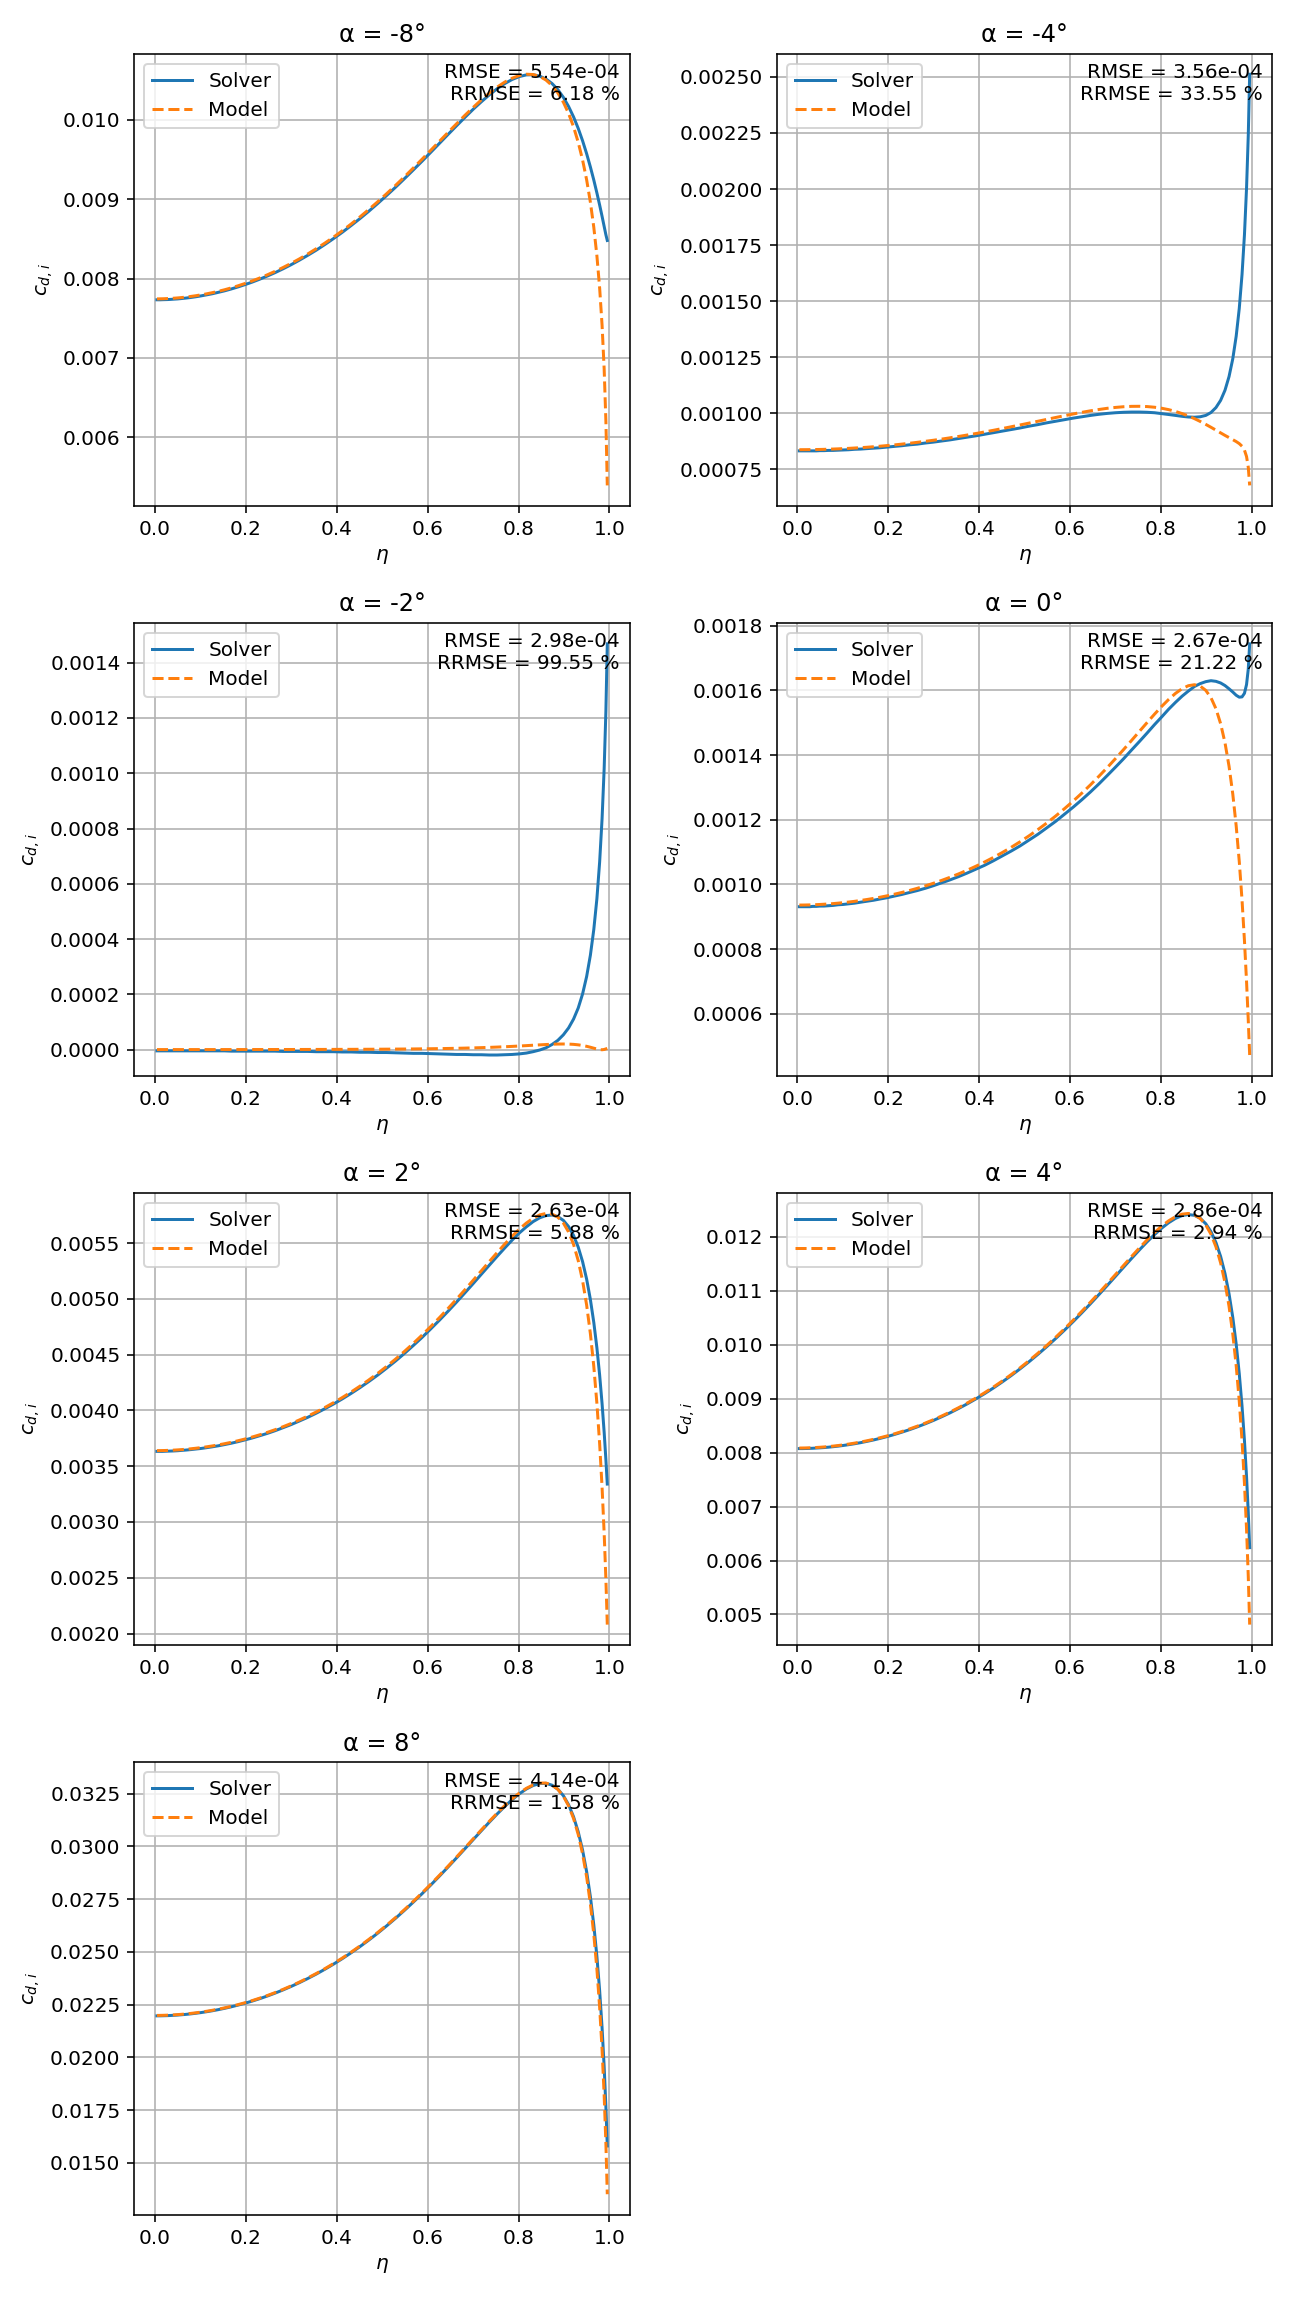

In [86]:
compare_coeff_predict(cd_aero_cam_table, eval_cd_pred_nomindrag_cam, "$c_{d, i}$", [-8, -4, -2, 0, 2, 4, 8])